### Configurations

In [3]:
# The cache directories:
cache_path       = '/data/crcns2021/hcpannot-cache'
image_cache_path = f'{cache_path}/annot-images'
v123_cache_path  = f'{cache_path}/annot-v123'
csulc_cache_path = f'{cache_path}/annot-csulc'
results_path = '/data/crcns2021/results'
contour_save_path = f'{results_path}/data_branch/save'
proc_path = f'{results_path}/proc'
traces_path = f'{proc_path}/traces'
paths_path = f'{proc_path}/paths'
labels_path = f'{proc_path}/labels'

#If you aren't using /data
import os
os.environ['HCPANNOT_LOAD_PATH'] = cache_path

### Dependencies

In [5]:
import os
import hcpannot
import numpy as np
import pandas as pd
import neuropythy as ny
import matplotlib as mpl
import matplotlib.pyplot as plt
from collections import defaultdict

from hcpannot.config import (
    subject_list,
    ventral_raters,
)


In [6]:
font = {'family': 'arial',
        'size' : 10}
mpl.rc('font', **font)

In [7]:
# define constants
sub_contours = ['hV4_outer','hV4_VO1','VO1_VO2','VO_outer']
sids = subject_list.copy()

### Create Fsaverage Dataframe

#### Sampling data points from the cache files

In [5]:
# use a random subject drawn by a random rater as an example before running all subjects
hemi = 'lh'
r = ventral_raters[1]
roi = sub_contours[1]
subject_id = sids[140]

path = os.path.join(proc_path, 'fsaverage', f"cacherater_{r}_{subject_id}_{hemi}_{roi}.mgz")
data = ny.load(path)

Text(0.5, 1.0, '680957 lh hV4_VO1 R2')

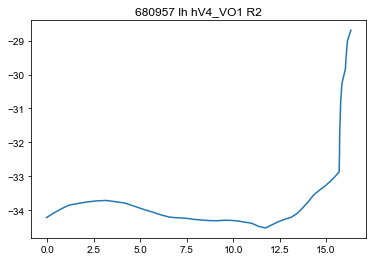

In [6]:
# the cache file includes x and y coordinates of 500 evenly spaced points along the contour
# to compute a linear mixed-effects model, we can use a subset of these points
# here we use every 10th point (50 points total)
sample_idx = np.arange(0, 500, 10)
data_x = data[0][sample_idx]
data_y = data[1][sample_idx]

# plot the contour using the subset of points
plt.plot(data_x, data_y)
plt.title(f'{subject_id} {hemi} {roi} {r}')

In [7]:
# sample the data points from the cache files for all subjects and raters
# and save them in a dataframe
# the dataframe has the following columns:
# value, coord, num_point, subject_id, hemi, roi, rater
data = []
missing = defaultdict(list)
for sid in sids:
    for r in ventral_raters:
        miss=False
        for roi in sub_contours:
            for hemi in ['lh', 'rh']:
                path = os.path.join(proc_path, 'fsaverage', f"cacherater_{r}_{sid}_{hemi}_{roi}.mgz")
                if os.path.isfile(path): # check if the cache file exists
                    datapoints = ny.load(path)
                    x_coord = datapoints[0][sample_idx]
                    y_coord = datapoints[1][sample_idx]
                    data.append([x_coord, y_coord, sid, hemi, roi, r])
                else: # if the cache file does not exist, add the subject to the missing list
                    miss = True
        if miss:
            missing[r].append(sid)

# save the data in a dataframe
df = pd.DataFrame(data, columns=['x_coord', 'y_coord', 'subject_id', 'hemi', 'contour', 'rater'])

# format the dataframe
df_fmt = df.explode(['x_coord','y_coord'])
df_fmt['rater'] = df_fmt['rater'].astype('category')
df_fmt['x_coord'] = df_fmt['x_coord'].astype('float')
df_fmt['y_coord'] = df_fmt['y_coord'].astype('float')
df_fmt['rater_code'] = df_fmt['rater'].cat.codes
df_fmt['loc_on_contour'] = df_fmt.groupby(level=0).cumcount()

df_fmt

# save the dataframe
# df_fmt.to_csv('df_LMM.csv')

,x_coord,y_coord,subject_id,hemi,contour,rater,rater_code,loc_on_contour
0,-9.843389,-5.616166,100610,lh,hV4_outer,R1,0,0
0,-9.852863,-6.966301,100610,lh,hV4_outer,R1,0,1
0,-10.106462,-7.982486,100610,lh,hV4_outer,R1,0,2
0,-10.512306,-8.820235,100610,lh,hV4_outer,R1,0,3
0,-10.727962,-9.770275,100610,lh,hV4_outer,R1,0,4
...,...,...,...,...,...,...,...,...
7235,-11.124606,-50.682114,995174,rh,VO_outer,R5,4,45
7235,-10.979109,-49.854111,995174,rh,VO_outer,R5,4,46
7235,-10.806480,-48.933819,995174,rh,VO_outer,R5,4,47
7235,-10.642167,-48.014641,995174,rh,VO_outer,R5,4,48


### Create Fsnative Dataframe

In [8]:
# sampling from fsnative data is similar to fsaverage data
data_native = []
sample_idx = np.arange(0, 500, 10)
missing = defaultdict(list)

for sid in sids:
    for r in ventral_raters:
        miss=False
        for roi in sub_contours:
            for hemi in ['lh', 'rh']:
                path = os.path.join(proc_path, 'fsnative_aligned', f"cacherater_{r}_{sid}_{hemi}_{roi}.mgz")
                if os.path.exists(path): # check if the cache file exists
                    datapoints = ny.load(path)
                    x_coord = datapoints[0][sample_idx]
                    y_coord = datapoints[1][sample_idx]
                    data_native.append([x_coord, y_coord, sid, hemi, roi, r])
                else: # if the cache file does not exist, add the subject to the missing list
                    miss=True 
        if miss:
            missing[r].append(sid)
            
# save the data in a dataframe
df_native = pd.DataFrame(data_native, columns=['x_coord', 'y_coord', 'subject_id', 'hemi', 'contour', 'rater'])

# format the dataframe
df_fnat = df_native.explode(['x_coord','y_coord'])
df_fnat['rater'] = df_fnat['rater'].astype('category')
df_fnat['x_coord'] = df_fnat['x_coord'].astype('float')
df_fnat['y_coord'] = df_fnat['y_coord'].astype('float')
df_fnat['rater_code'] = df_fnat['rater'].cat.codes
df_fnat['loc_on_contour'] = df_fnat.groupby(level=0).cumcount()

df_fnat

# save the dataframe
# df_fnat.to_csv('df_LMM_native_aligned.csv')

,x_coord,y_coord,subject_id,hemi,contour,rater,rater_code,loc_on_contour
0,-14.240262,1.235579,100610,lh,hV4_outer,R1,0,0
0,-14.919656,0.190854,100610,lh,hV4_outer,R1,0,1
0,-15.599050,-0.853872,100610,lh,hV4_outer,R1,0,2
0,-16.278442,-1.898596,100610,lh,hV4_outer,R1,0,3
0,-16.784143,-3.019203,100610,lh,hV4_outer,R1,0,4
...,...,...,...,...,...,...,...,...
7235,-11.359633,-51.666348,995174,rh,VO_outer,R5,4,45
7235,-10.564707,-50.913841,995174,rh,VO_outer,R5,4,46
7235,-9.769778,-50.161335,995174,rh,VO_outer,R5,4,47
7235,-8.974851,-49.408829,995174,rh,VO_outer,R5,4,48


### Running the Linear Mixed-Effect Model in R

### Read the results into `pandas` dataframes and format

In [8]:
result_dir = 'lmm_results'
result_ave = pd.read_csv(os.path.join(result_dir, 'lm_result_average.csv'), index_col=0)

result_nat = pd.read_csv(os.path.join(result_dir, 'lm_result_native_aligned.csv'), index_col=0)

### Clean results

In [9]:
# instead of changing the result, drop the invalid data points
result_ave = hcpannot.analysis.postprocess_result(result_ave)
result_nat = hcpannot.analysis.postprocess_result(result_nat, native_aligned=True)

In [10]:
result_ave

,varex_rater,varex_sbj,hemi,contour,loc_on_contour,residual
0,0.029365,0.721202,lh,VO1_VO2,0,0.249432
1,0.027621,0.727945,lh,VO1_VO2,1,0.244434
2,0.026021,0.733891,lh,VO1_VO2,2,0.240087
3,0.024597,0.739206,lh,VO1_VO2,3,0.236197
4,0.023381,0.744067,lh,VO1_VO2,4,0.232553
...,...,...,...,...,...,...
395,0.132034,0.520408,rh,hV4_outer,45,0.347558
396,0.134052,0.511366,rh,hV4_outer,46,0.354582
397,0.135669,0.502572,rh,hV4_outer,47,0.361759
398,0.136936,0.493327,rh,hV4_outer,48,0.369738


In [11]:
result_nat

,varex_rater,varex_sbj,hemi,contour,loc_on_contour,residual
0,0.023446,0.781493,lh,VO1_VO2,0,0.195061
1,0.021440,0.791388,lh,VO1_VO2,1,0.187172
2,0.019547,0.800873,lh,VO1_VO2,2,0.179580
3,0.017769,0.809957,lh,VO1_VO2,3,0.172274
4,0.016117,0.818618,lh,VO1_VO2,4,0.165265
...,...,...,...,...,...,...
395,0.070527,0.748571,rh,hV4_outer,45,0.180902
396,0.073182,0.741590,rh,hV4_outer,46,0.185227
397,0.076056,0.734426,rh,hV4_outer,47,0.189518
398,0.079269,0.726319,rh,hV4_outer,48,0.194413


### Visulization of result

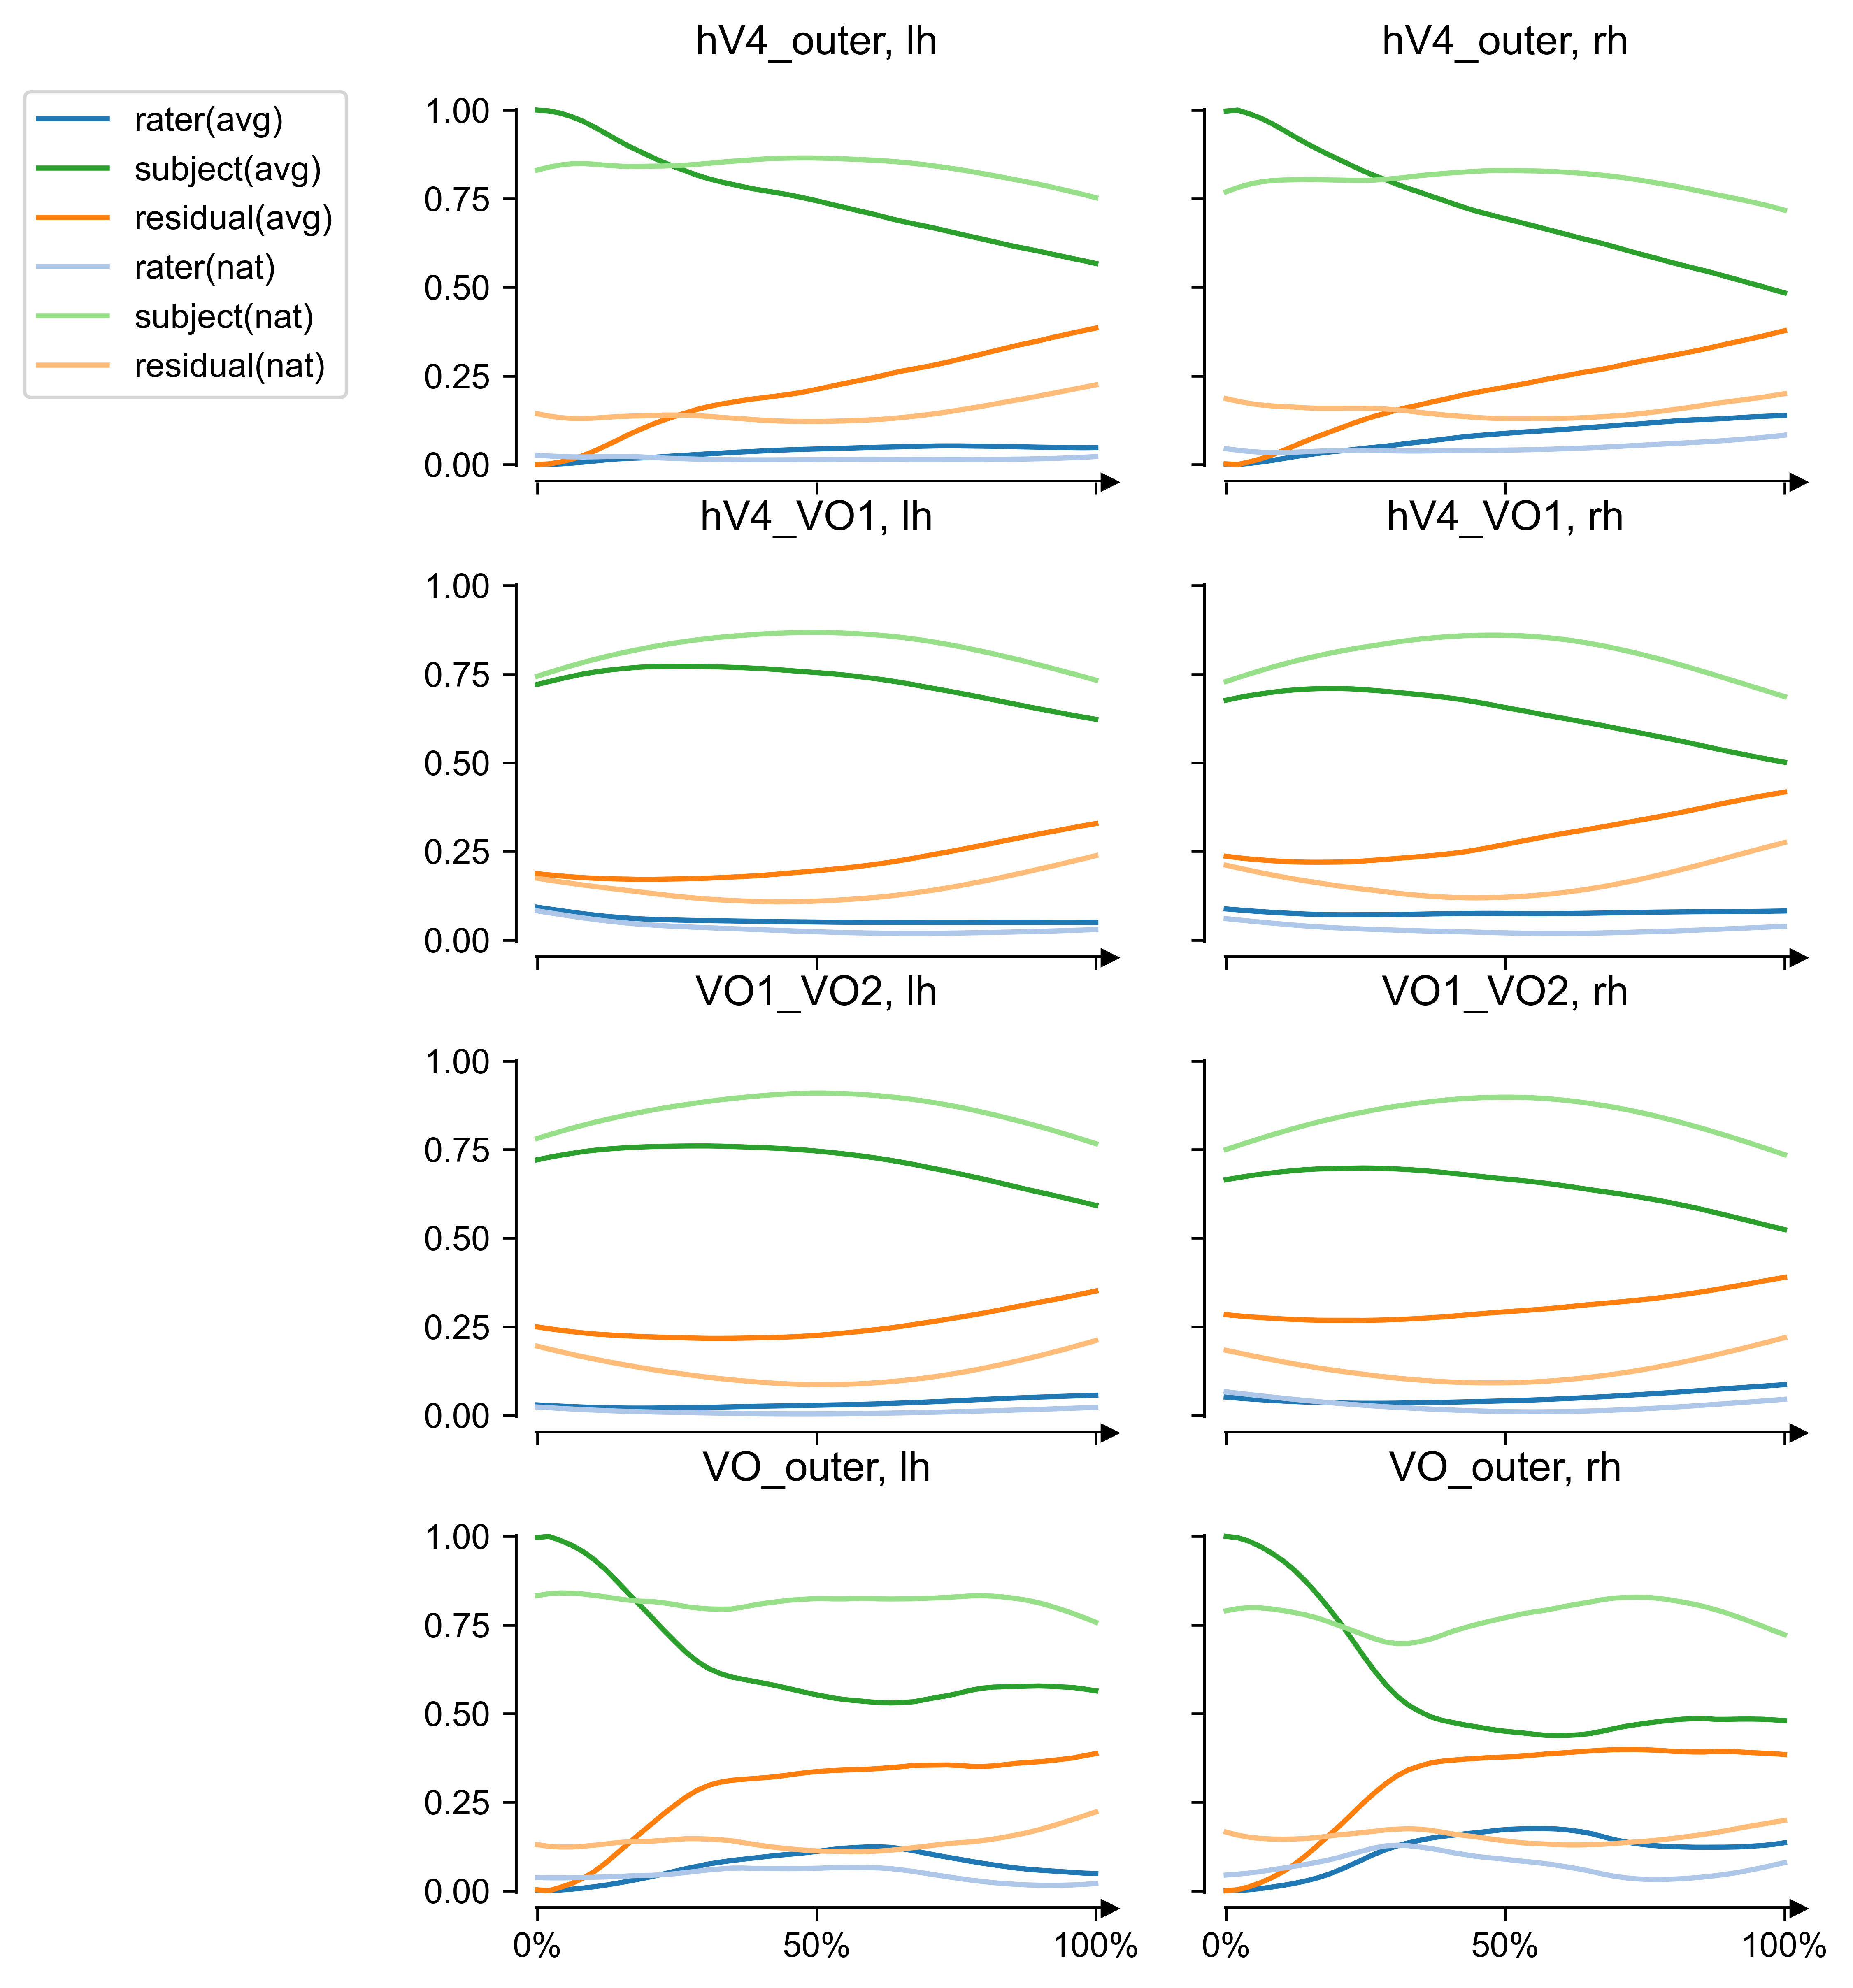

In [12]:
(fig, ax) = plt.subplots(len(sub_contours), 2, figsize=(6,8), dpi=600, sharey=True, sharex=True)
fig.tight_layout()

# fig.suptitle ('Variance Explained by Rater, Subject, and residual', y=1.05)
# fig.supxlabel('Location on Contour', y=-0.05)
# fig.supylabel('Variance Explained', x=-0.07)

colors = {
    'rater(avg)': '#1f77b4',
    'rater(nat)': '#aec7e8',
    'subject(avg)': '#2ca02c',
    'subject(nat)': '#98df8a',
    'residual(avg)': '#ff7f0e',
    'residual(nat)': '#ffbb78'
}

# plot the data for each contour
for i, contour in enumerate(sub_contours):
    
    # get the data for the contour
    ave_result = hcpannot.analysis.get_contour_data(result_ave, contour)
    nat_result = hcpannot.analysis.get_contour_data(result_nat, contour)
        
    # plot the data for each space
    for data, space in zip([ave_result, nat_result], ['avg', 'nat']):
        
        # plot the data for each hemisphere
        for j, hemi in enumerate(['lh', 'rh']):
            
            # get the data for the hemisphere
            hemi_data = data[hemi]
            
            # plot the rater
            label = f'rater({space})'
            ax[i,j].plot(hemi_data['rater'], label=label, c=colors[label])
            
            # plot the subject
            label = f'subject({space})'
            ax[i,j].plot(hemi_data['sbj'], label=label, c=colors[label])

            # plot the residual
            label = f'residual({space})'
            ax[i,j].plot(hemi_data['residual'], label=label, c=colors[label])


            # format the plot
            ax[i,j].set_title(f'{contour}, {hemi}')
            ax[i,j].set_xlim(-2, 51)
            ax[i,j].set_ylim(-0.05,1.1)
            ax[i,j].spines['top'].set_visible(False)
            ax[i,j].spines['right'].set_visible(False)
            ax[i,j].spines['left'].set_visible(False)
            ax[i,j].spines['bottom'].set_visible(False)
            ax[i,j].plot([-2,-2], [0,1], 'k-', lw=1.5)
            ax[i,j].plot([0,50], [-0.05, -0.05], 'k-', lw=1.5)
            
            # set the x-axis labels
            ticks = np.linspace(0, 49, num = 3)
            labels = [f'{num/49*100:.0f}%' for num in ticks]

            ax[i,j].set_xticks(ticks=ticks, labels=labels)
            ax[i,j].plot(0.985, -0.05, ">k", markersize=4, transform=ax[i,j].get_yaxis_transform(), clip_on=False)
            
h, l = ax[0,0].get_legend_handles_labels()
ax[0,0].legend(h, l, fontsize=10, bbox_to_anchor=(-0.25, 1))

In [25]:
# Same as above but removed subplot titles and adjusted spacing for making the figure for the paper

# (fig, ax) = plt.subplots(len(sub_contours), 2, figsize=(3.25,4), dpi=1200, sharey=True, sharex=True)
# fig.tight_layout(pad=0.01)


# colors = {
#     'rater(avg)': '#1f77b4',
#     'rater(nat)': '#aec7e8',
#     'subject(avg)': '#2ca02c',
#     'subject(nat)': '#98df8a',
#     'residual(avg)': '#ff7f0e',
#     'residual(nat)': '#ffbb78'
# }

# # plot the data for each contour
# for i, contour in enumerate(sub_contours):
    
#     # get the data for the contour
#     ave_result = get_contour_data(result_ave, contour)
#     nat_result = get_contour_data(result_nat, contour)
        
#     # plot the data for each space
#     for data, space in zip([ave_result, nat_result], ['avg', 'nat']):
        
#         # plot the data for each hemisphere
#         for j, hemi in enumerate(['lh', 'rh']):
            
#             # get the data for the hemisphere
#             hemi_data = data[hemi]
            
#             # plot the rater
#             label = f'rater({space})'
#             ax[i,j].plot(hemi_data['rater'], label=label, c=colors[label])
            
#             # plot the subject
#             label = f'subject({space})'
#             ax[i,j].plot(hemi_data['sbj'], label=label, c=colors[label])

#             # plot the residual
#             label = f'residual({space})'
#             ax[i,j].plot(hemi_data['residual'], label=label, c=colors[label])

#             # format the plot
#             # ax[i,j].set_title(f'{contour}, {hemi}')
#             ax[i,j].set_xlim(-2, 51)
#             ax[i,j].set_ylim(-0.05,1.1)
#             ax[i,j].spines['top'].set_visible(False)
#             ax[i,j].spines['right'].set_visible(False)
#             ax[i,j].spines['left'].set_visible(False)
#             ax[i,j].spines['bottom'].set_visible(False)
#             ax[i,j].plot([-2,-2], [0,1], 'k-', lw=1.5)
#             ax[i,j].plot([0,50], [-0.05, -0.05], 'k-', lw=1.5)
            
#             # set the x-axis labels
#             ticks = np.linspace(0, 49, num = 3)
#             labels = [f'{num/49*100:.0f}%' for num in ticks]

#             ax[i,j].set_xticks(ticks=ticks, labels=labels)
#             ax[i,j].plot(0.985, -0.05, ">k", markersize=4, transform=ax[i,j].get_yaxis_transform(), clip_on=False)
            
# # h, l = ax[0,0].get_legend_handles_labels()
# # ax[0,0].legend(h, l, fontsize=12, bbox_to_anchor=(-0.25, 1))
# # plt.savefig('variance_line.pdf', bbox_inches='tight')

## Visualizing ratio of variance explained by rater to subject

### Calculate ratio of vriance explained by rater to subject

In [13]:
# calculate ratio of variance explained by researcher to that by subject
result_ave['r2s_variance'] = result_ave['varex_rater'] / result_ave['varex_sbj']
result_nat['r2s_variance'] = result_nat['varex_rater'] / result_nat['varex_sbj']

### Visualization

/tmp/ipykernel_14008/1893340133.py:3: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


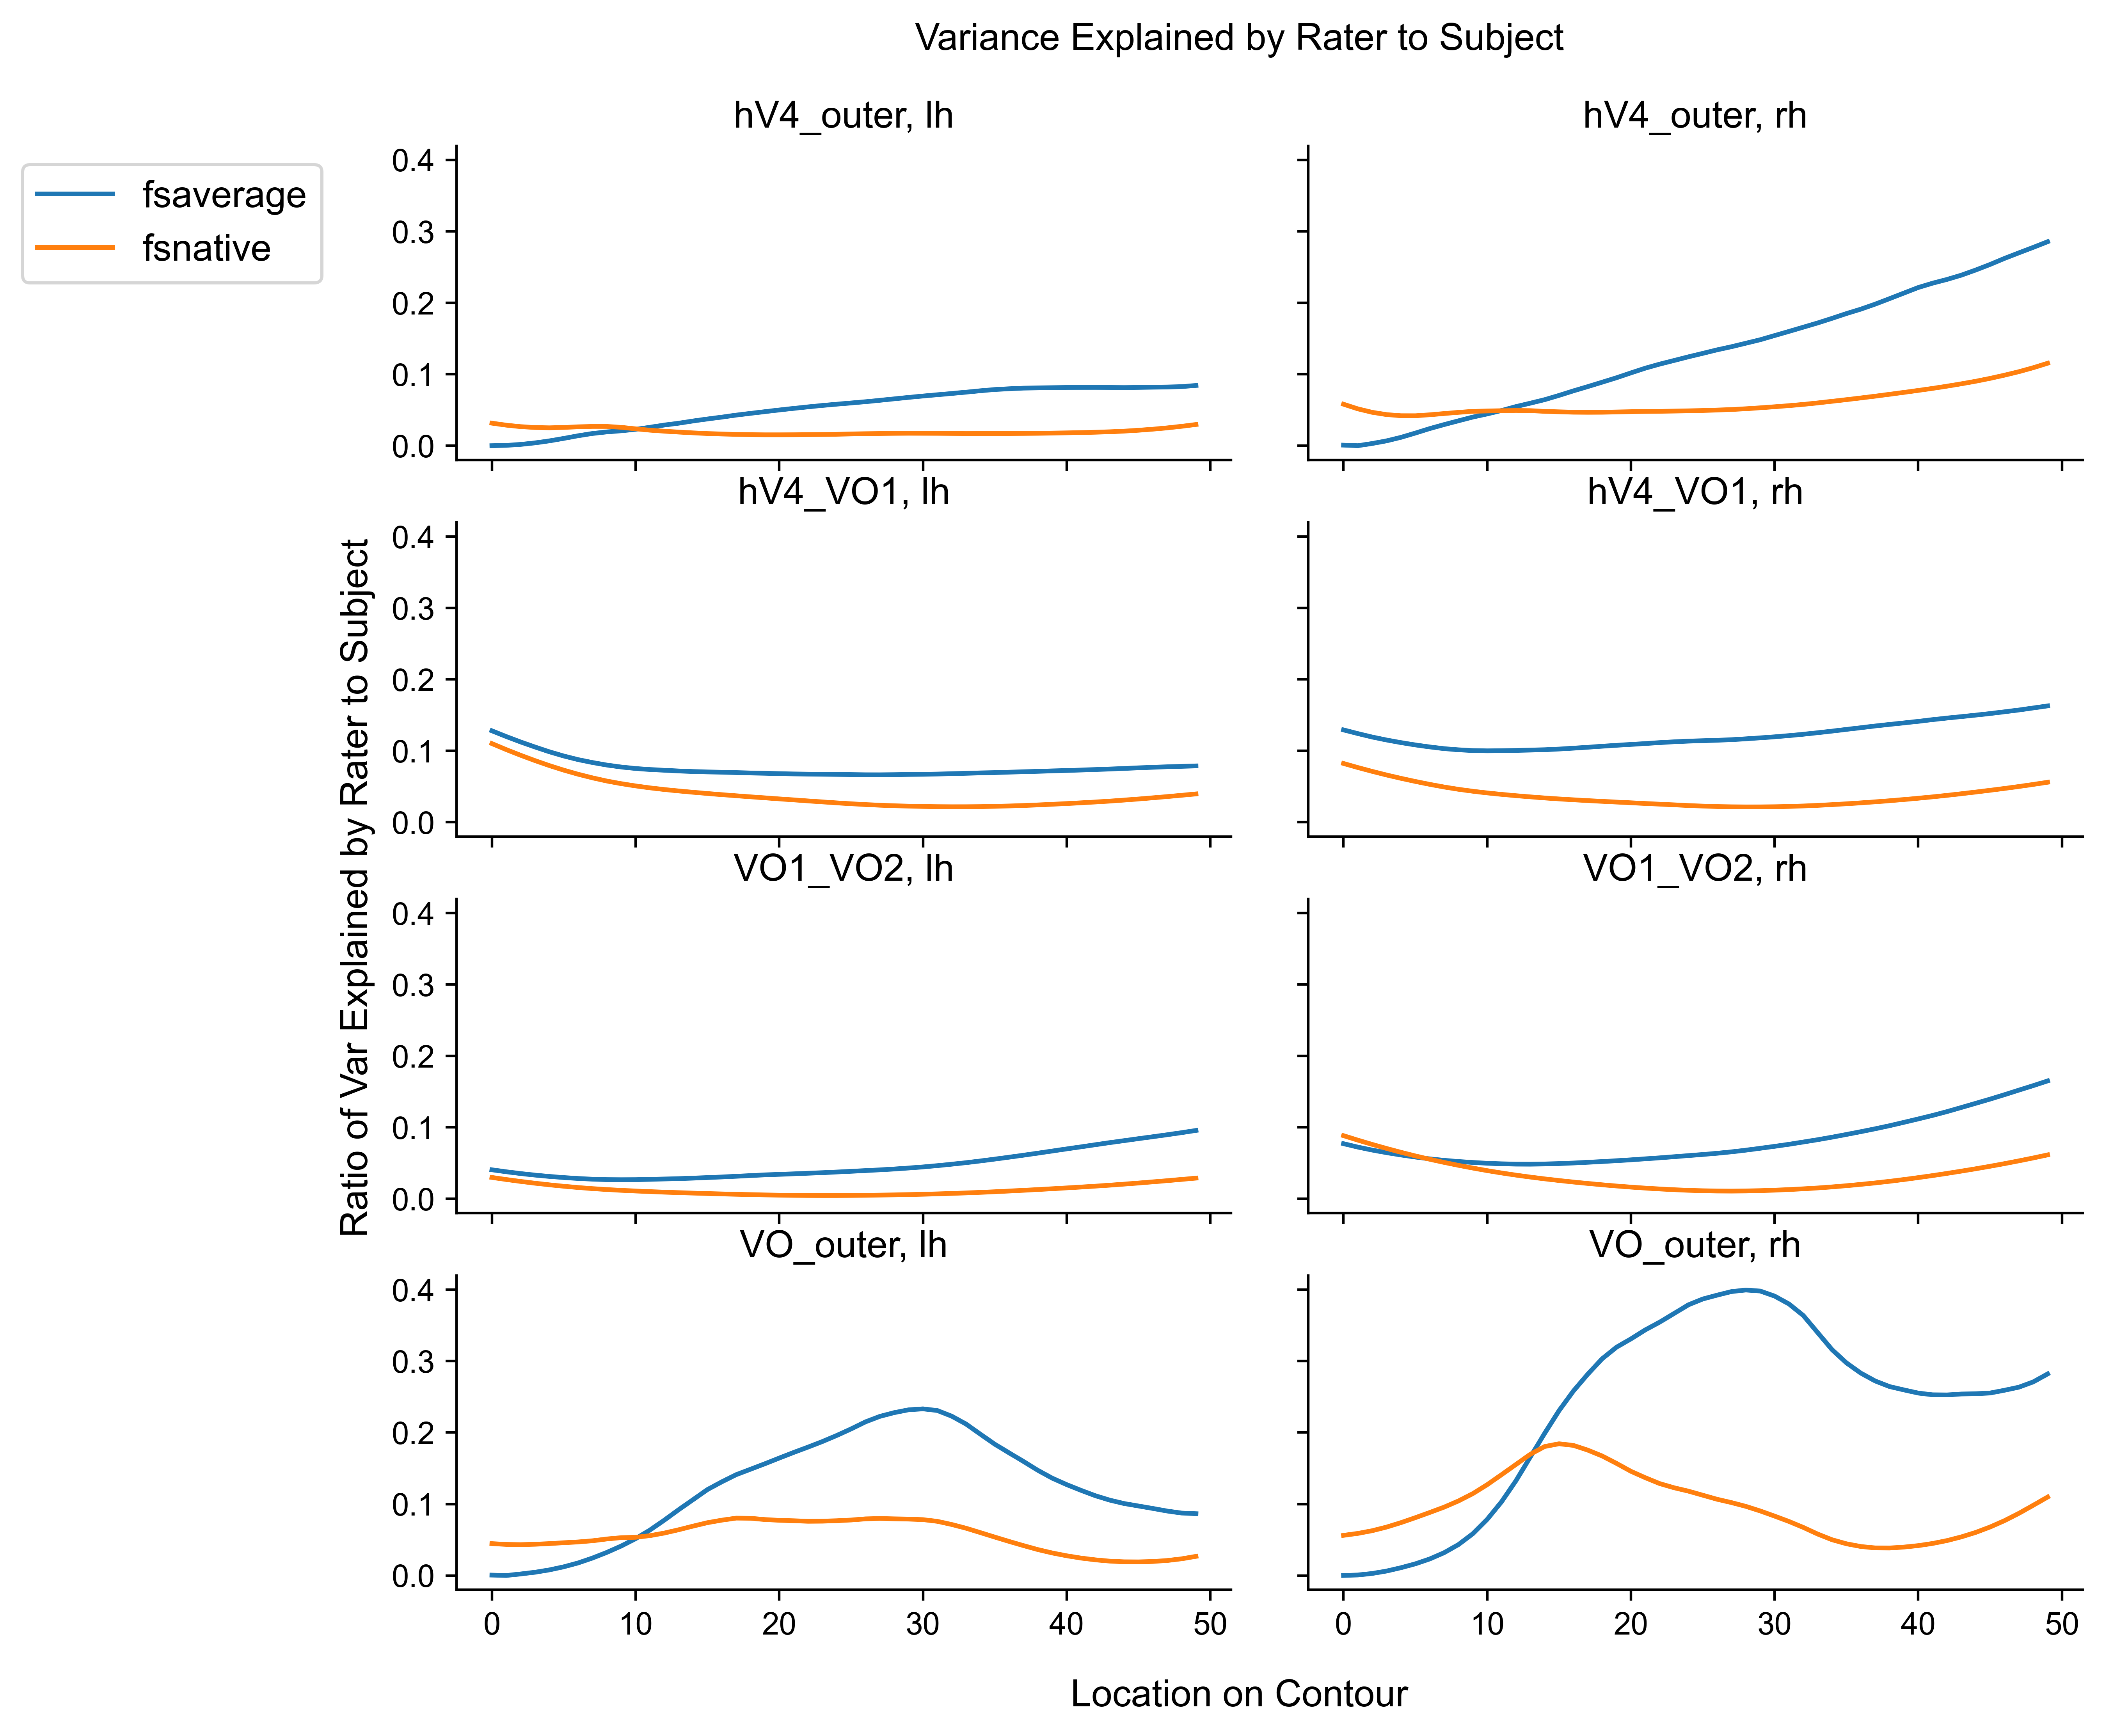

In [14]:
(fig, ax) = plt.subplots(len(sub_contours), 2, figsize=(8,7), dpi= 72*8, sharey=True, sharex=True, 
                         layout="constrained")
plt.tight_layout()
fig.suptitle ('Variance Explained by Rater to Subject', y=1.05)
fig.supxlabel('Location on Contour', y=-0.025)
fig.supylabel('Ratio of Var Explained by Rater to Subject', x=0)

for i, contour in enumerate(sub_contours):
    
    data_lh = result_ave[(result_ave['hemi'] == 'lh') & (result_ave['contour'] == contour)]  
    data_rh = result_ave[(result_ave['hemi'] == 'rh') & (result_ave['contour'] == contour)]
        
    data_lh_nat = result_nat[(result_nat['hemi'] == 'lh') & (result_nat['contour'] == contour)]
    data_rh_nat = result_nat[(result_nat['hemi'] == 'rh') & (result_nat['contour'] == contour)]  
    
    ax[i,0].plot(np.arange(50), data_lh['r2s_variance'], label='fsaverage')
    ax[i,1].plot(np.arange(50), data_rh['r2s_variance'], label='fsaverage')
    
    ax[i,0].plot(np.arange(50), data_lh_nat['r2s_variance'], label='fsnative')
    ax[i,1].plot(np.arange(50), data_rh_nat['r2s_variance'], label='fsnative')
    
    ax[i,0].set_title(f'{contour}, lh')
    ax[i,1].set_title(f'{contour}, rh')
    
    for j in [0,1]:
        ax[i,j].spines['top'].set_visible(False)
        ax[i,j].spines['right'].set_visible(False)

h, l = ax[0,0].get_legend_handles_labels()
ax[0,0].legend(h, l, fontsize=12, bbox_to_anchor=(-0.15, 1))

#fig.savefig('images/rater2sbj_variance.png', bbox_inches='tight')

### Hemispheric asymmetry

/tmp/ipykernel_14008/3957242163.py:5: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


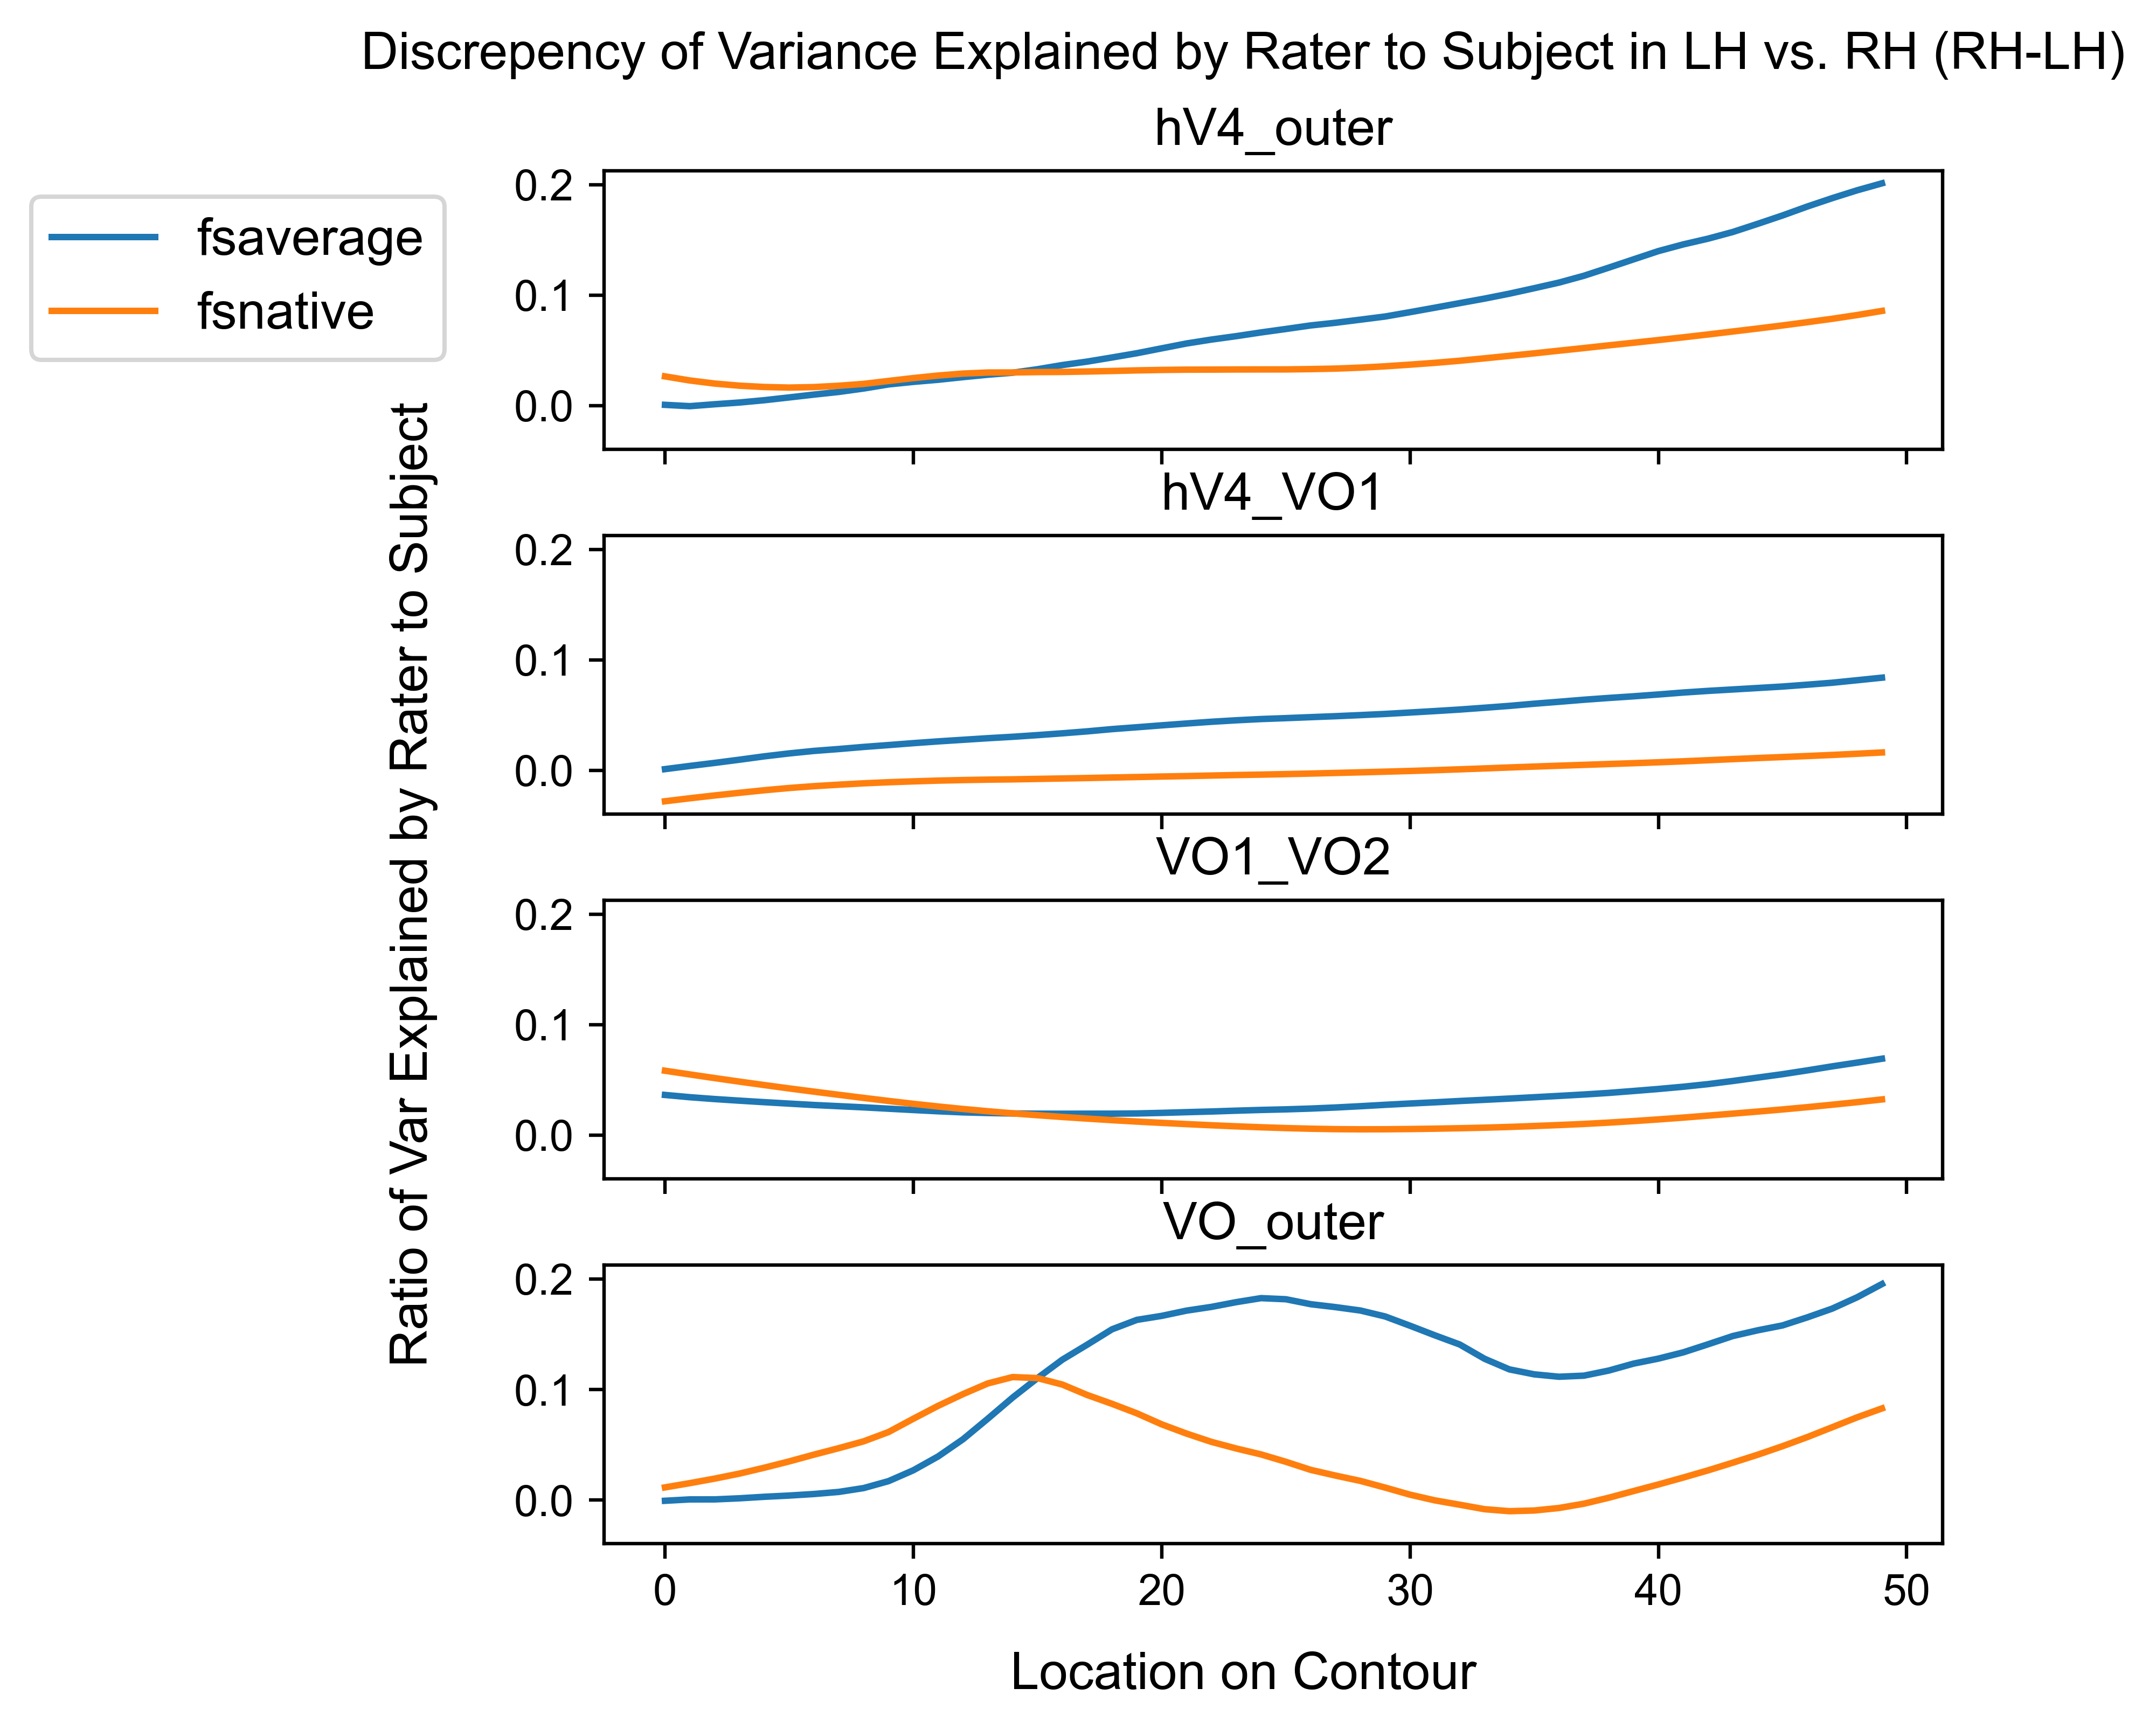

In [15]:
# visualize the hemispheric assymetry of the variance explained by rater to subject

(fig, ax) = plt.subplots(len(sub_contours), 1, figsize=(5,5), dpi=72*8, sharey=True, sharex=True, 
                         layout="constrained")
plt.tight_layout()
fig.suptitle ('Discrepency of Variance Explained by Rater to Subject in LH vs. RH (RH-LH)', y=1.05)
fig.supxlabel('Location on Contour', y=-0.025)
fig.supylabel('Ratio of Var Explained by Rater to Subject', x=-0.05)

for i, contour in enumerate(sub_contours):
    
    avg_result = hcpannot.analysis.get_contour_data(result_ave, contour)
    nat_result = hcpannot.analysis.get_contour_data(result_nat, contour)
    
    ax[i].plot(np.arange(50), avg_result['rh']['r2s_variance'] - avg_result['lh']['r2s_variance'], label='fsaverage')
    ax[i].plot(np.arange(50), nat_result['rh']['r2s_variance'] - nat_result['lh']['r2s_variance'], label='fsnative')

    ax[i].set_title(contour)

h, l = ax[0].get_legend_handles_labels()
ax[0].legend(h, l, fontsize=12, bbox_to_anchor=(-0.1, 1))

#fig.savefig('images/rater2sbj_variance.pdf', bbox_inches='tight')

### Plot line width plot of ratio of variance explained by rater to subject

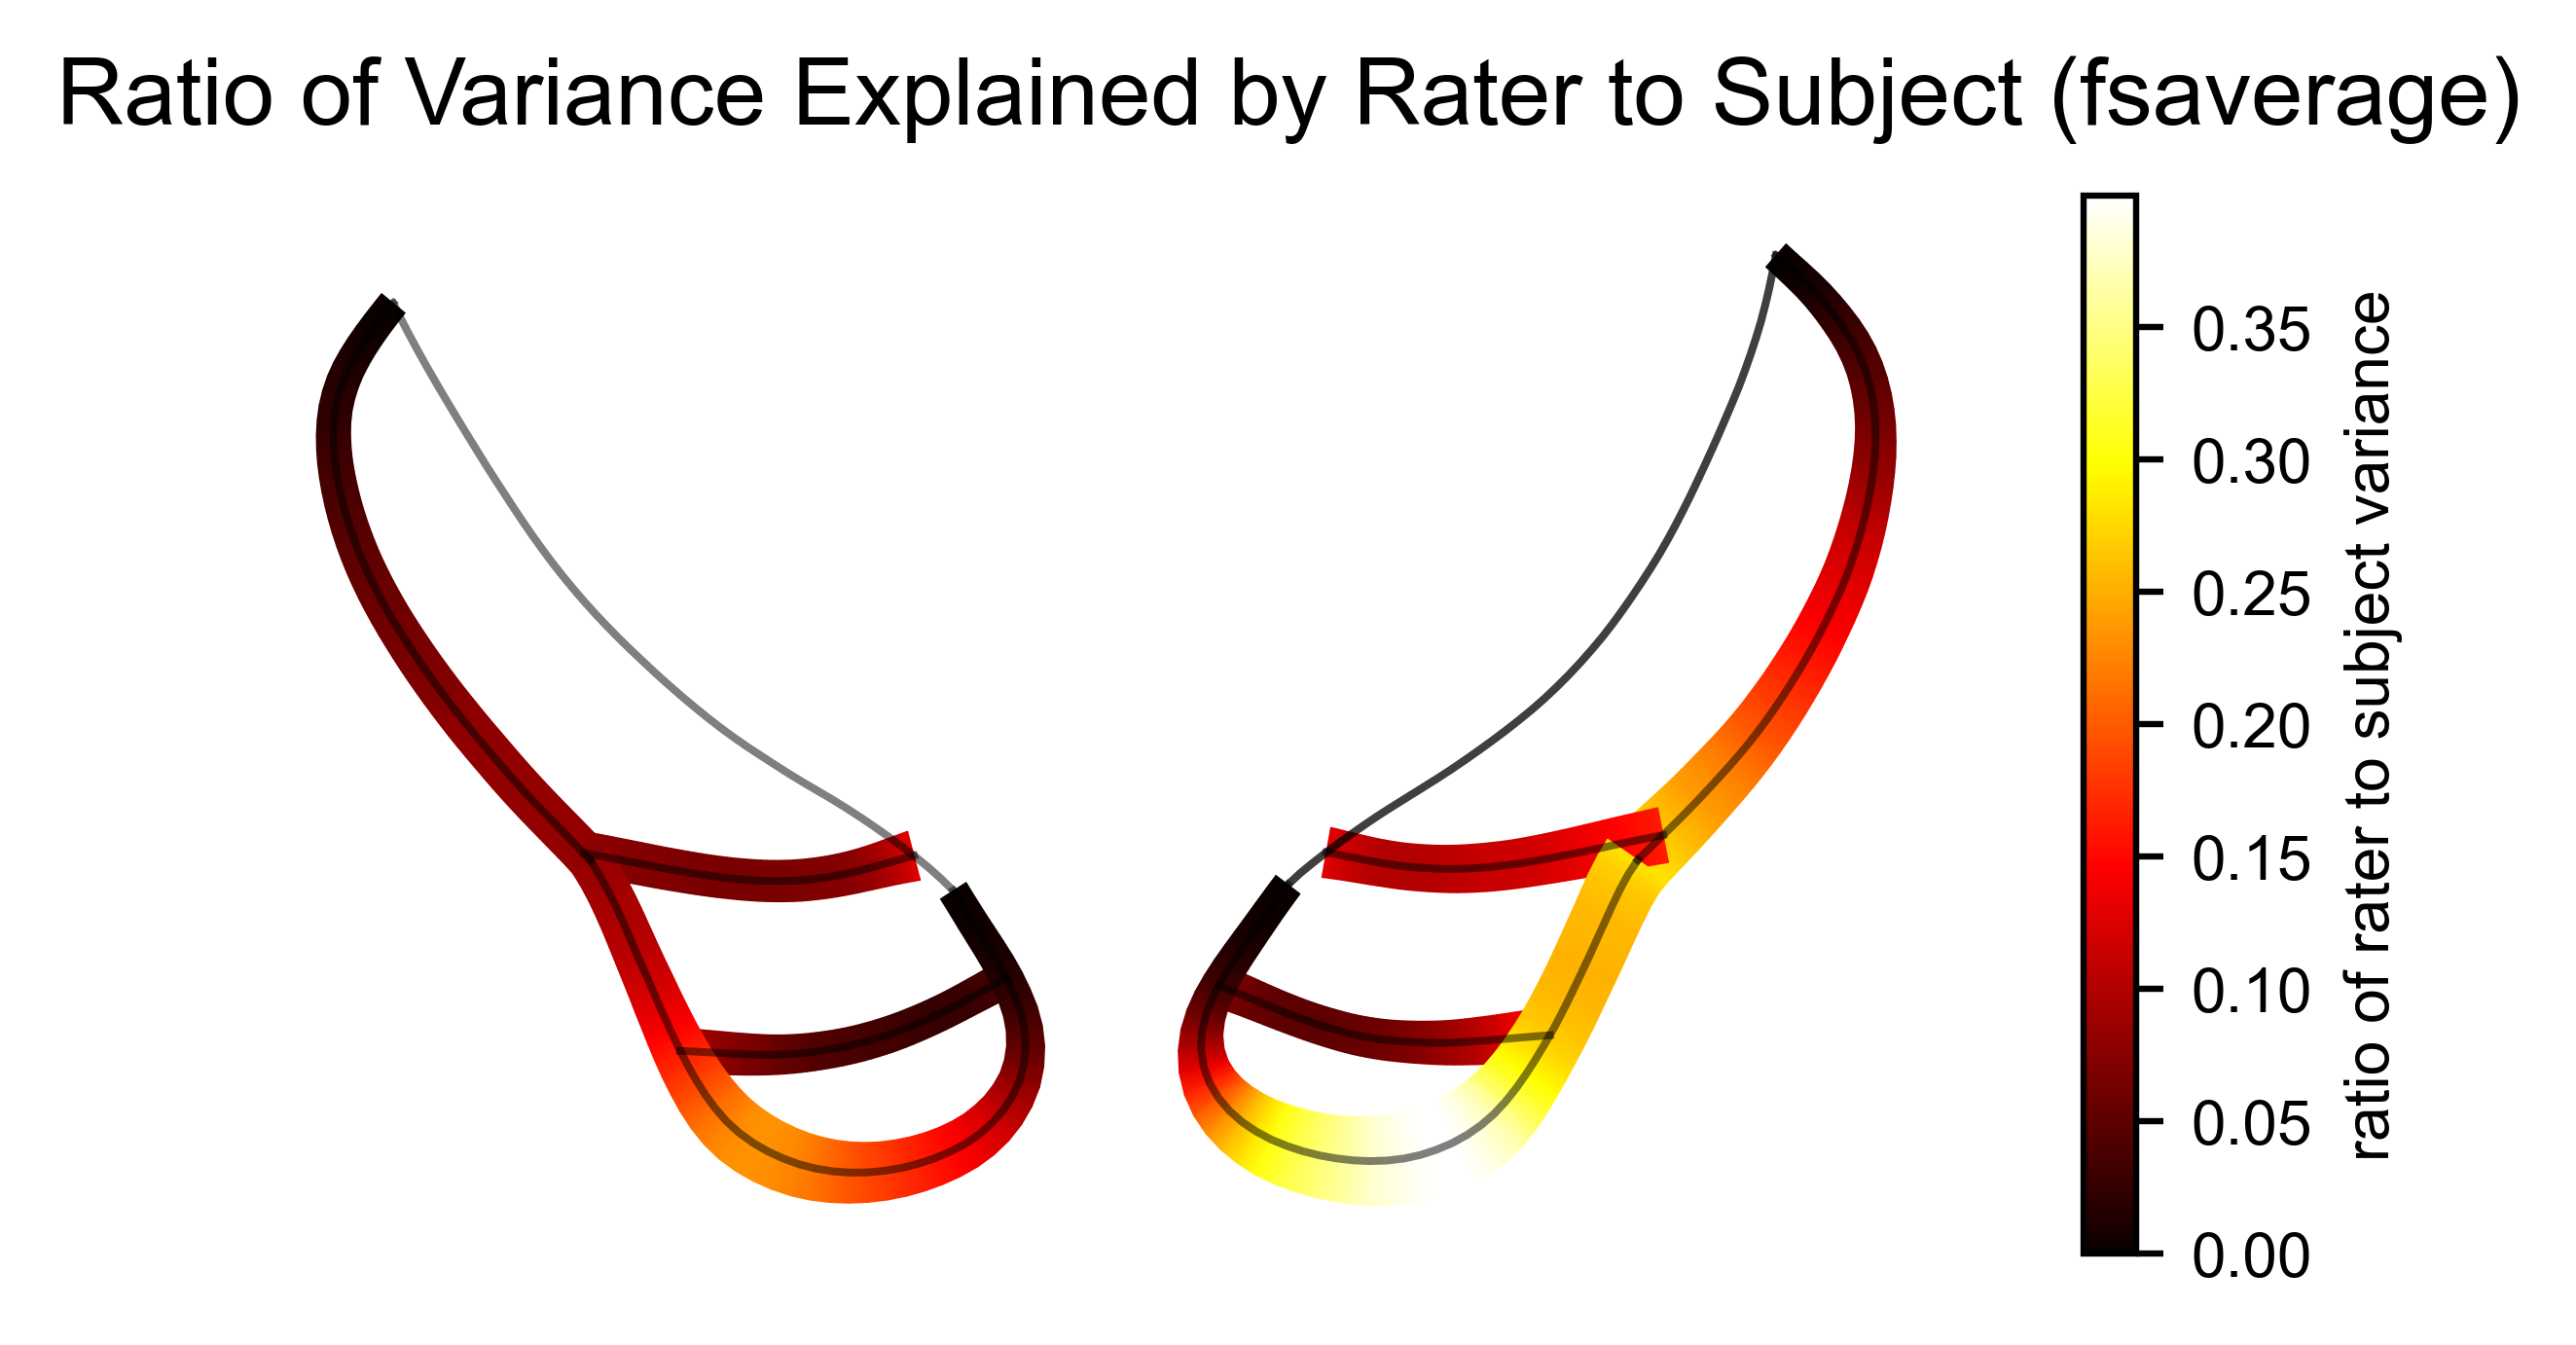

In [16]:
(fig,ax) = plt.subplots(1, 1, figsize = (5,2.5), dpi = 72*8)
fig.suptitle('Ratio of Variance Explained by Rater to Subject (fsaverage)')

ax.axis('off')

for i, hemi in enumerate(['lh', 'rh']):    
    hmap = hcpannot.analysis.plot_lw(result_ave, hemi, sub_contours, flatmap=False, contour_save_path=contour_save_path, proc_path=proc_path, ax=ax)
    
cb = fig.colorbar(hmap)
cb.ax.tick_params(labelsize=8)
cb.set_label('ratio of rater to subject variance', fontsize=8)

#plt.savefig('images/rater2sbj_variance_fsaverage.png')

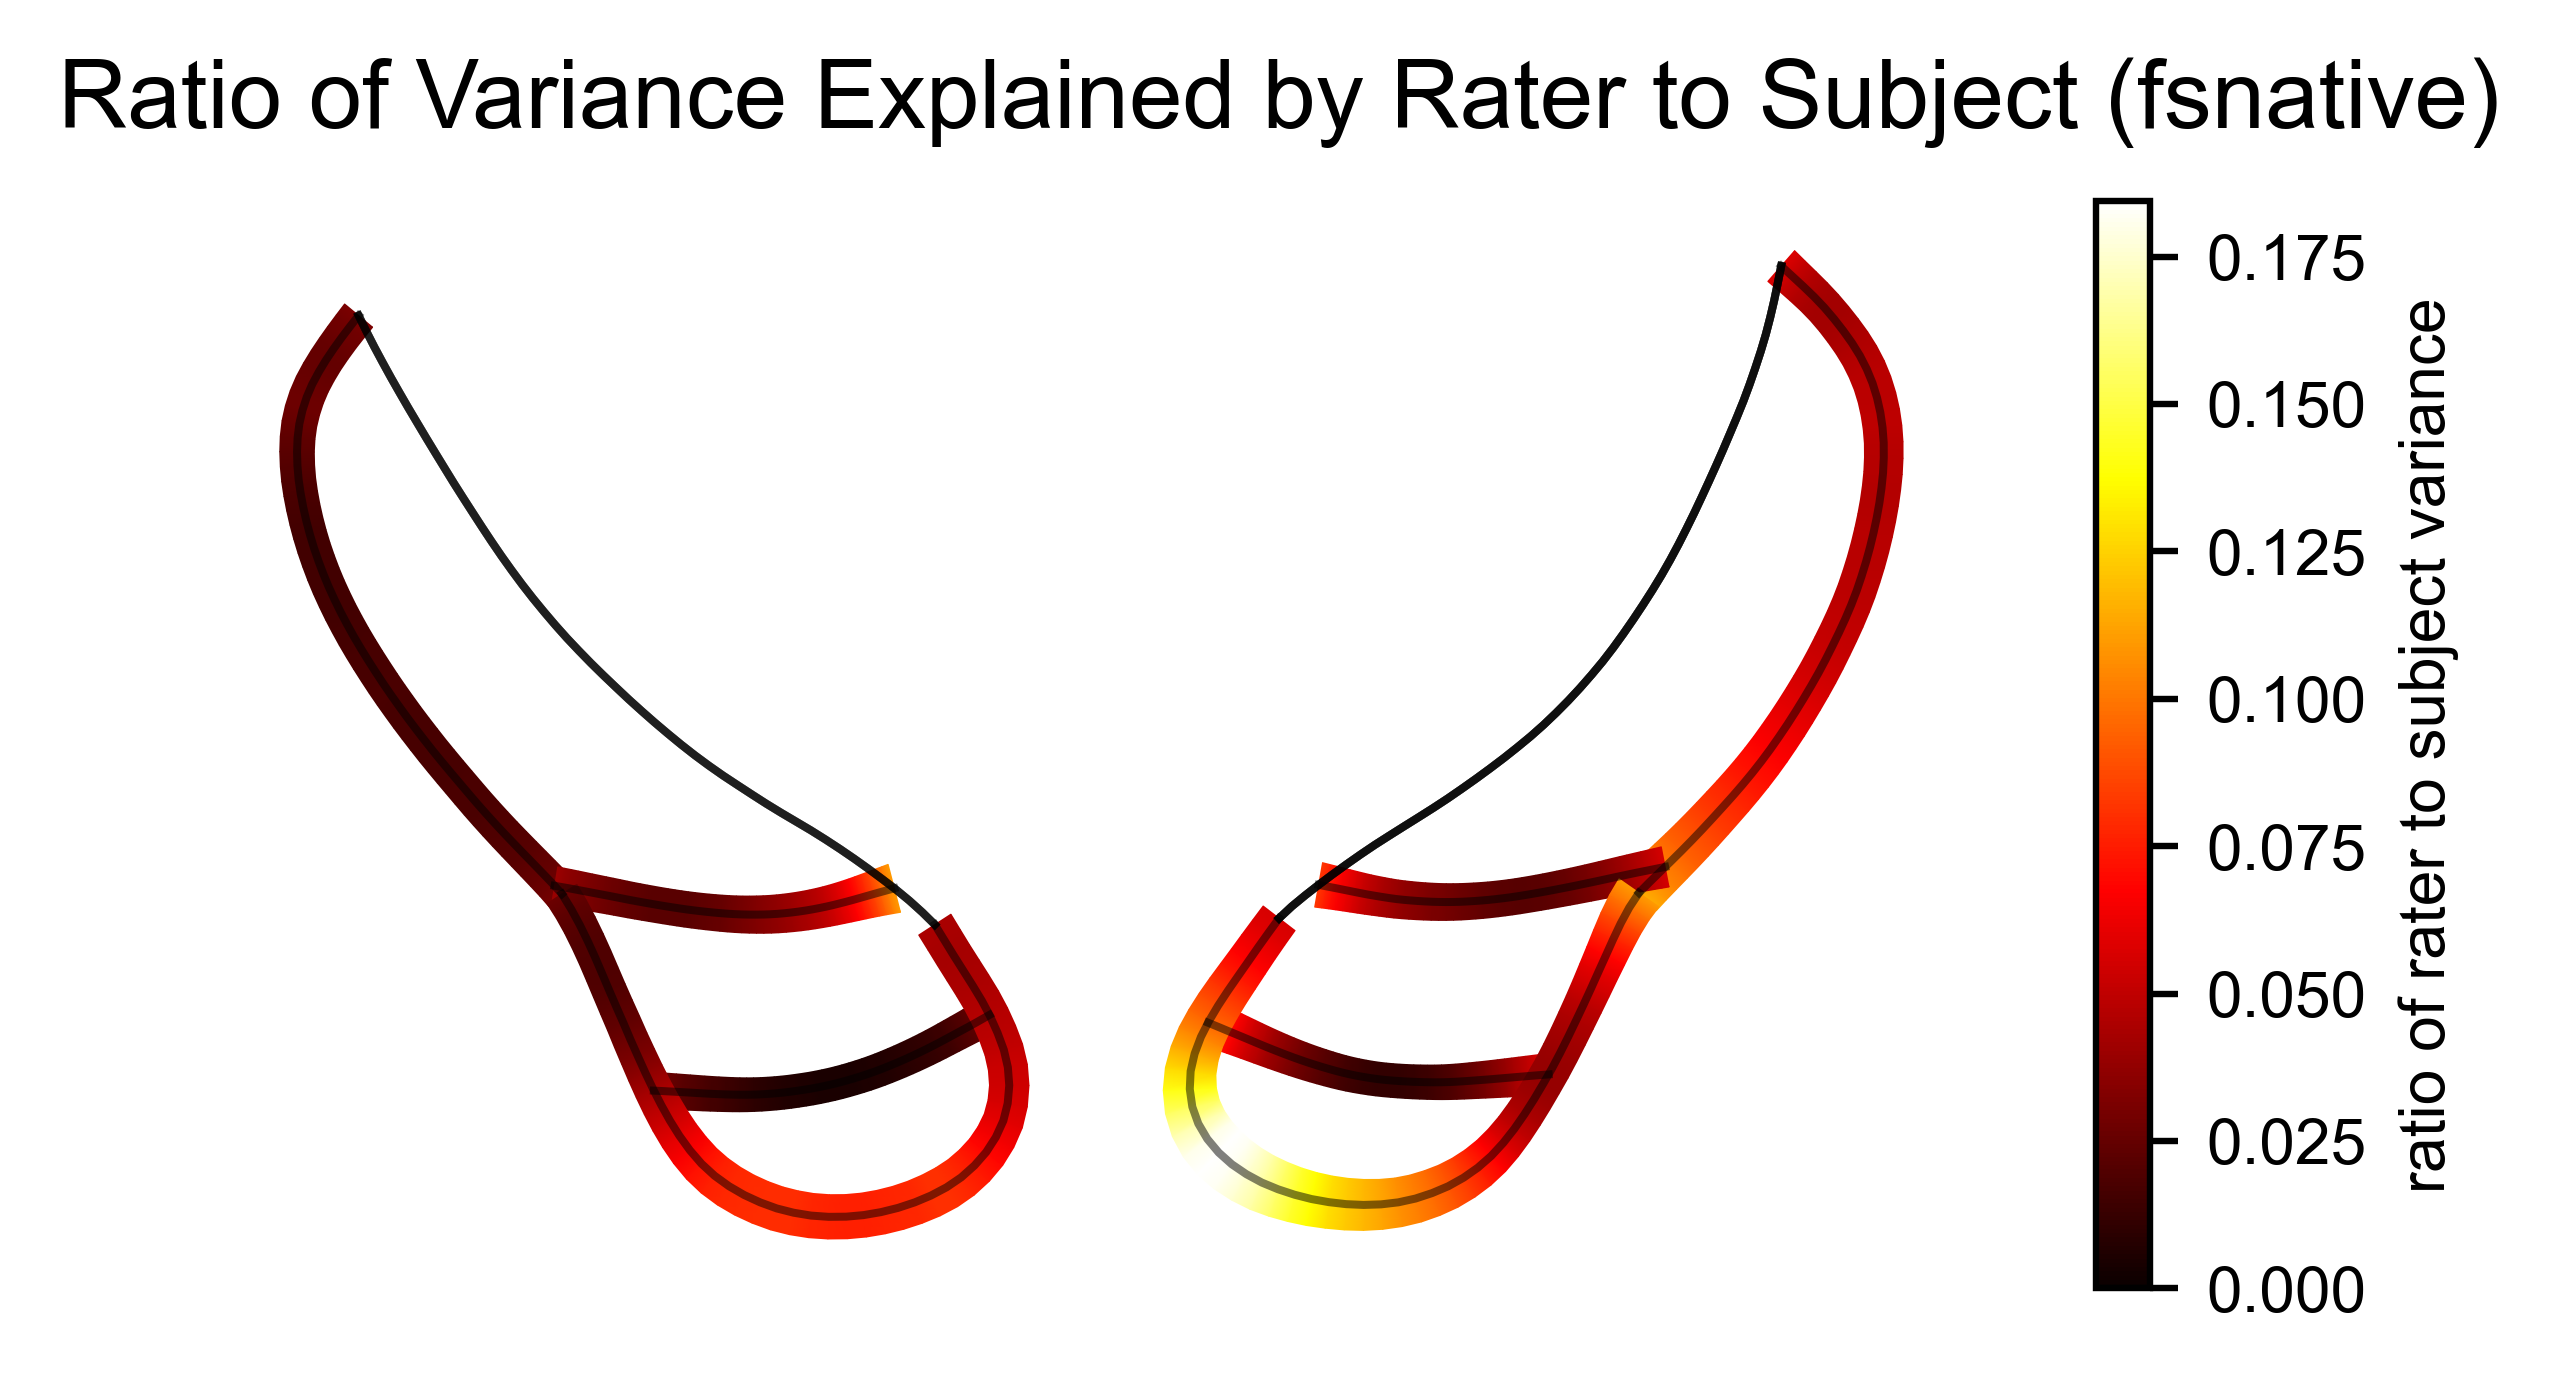

In [17]:
(fig,ax) = plt.subplots(1, 1, figsize = (5,2.5), dpi = 72*8)
fig.suptitle('Ratio of Variance Explained by Rater to Subject (fsnative)')

ax.axis('off')

for i, hemi in enumerate(['lh', 'rh']):    
    hmap = hcpannot.analysis.plot_lw(result_nat, hemi, sub_contours, flatmap=False, contour_save_path=contour_save_path, proc_path=proc_path, ax=ax)
    
cb = fig.colorbar(hmap)
cb.ax.tick_params(labelsize=8)
cb.set_label('ratio of rater to subject variance', fontsize=8)

#plt.savefig('images/rater2sbj_variance_fsaverage.png')

### Linewidth plot on flatmap

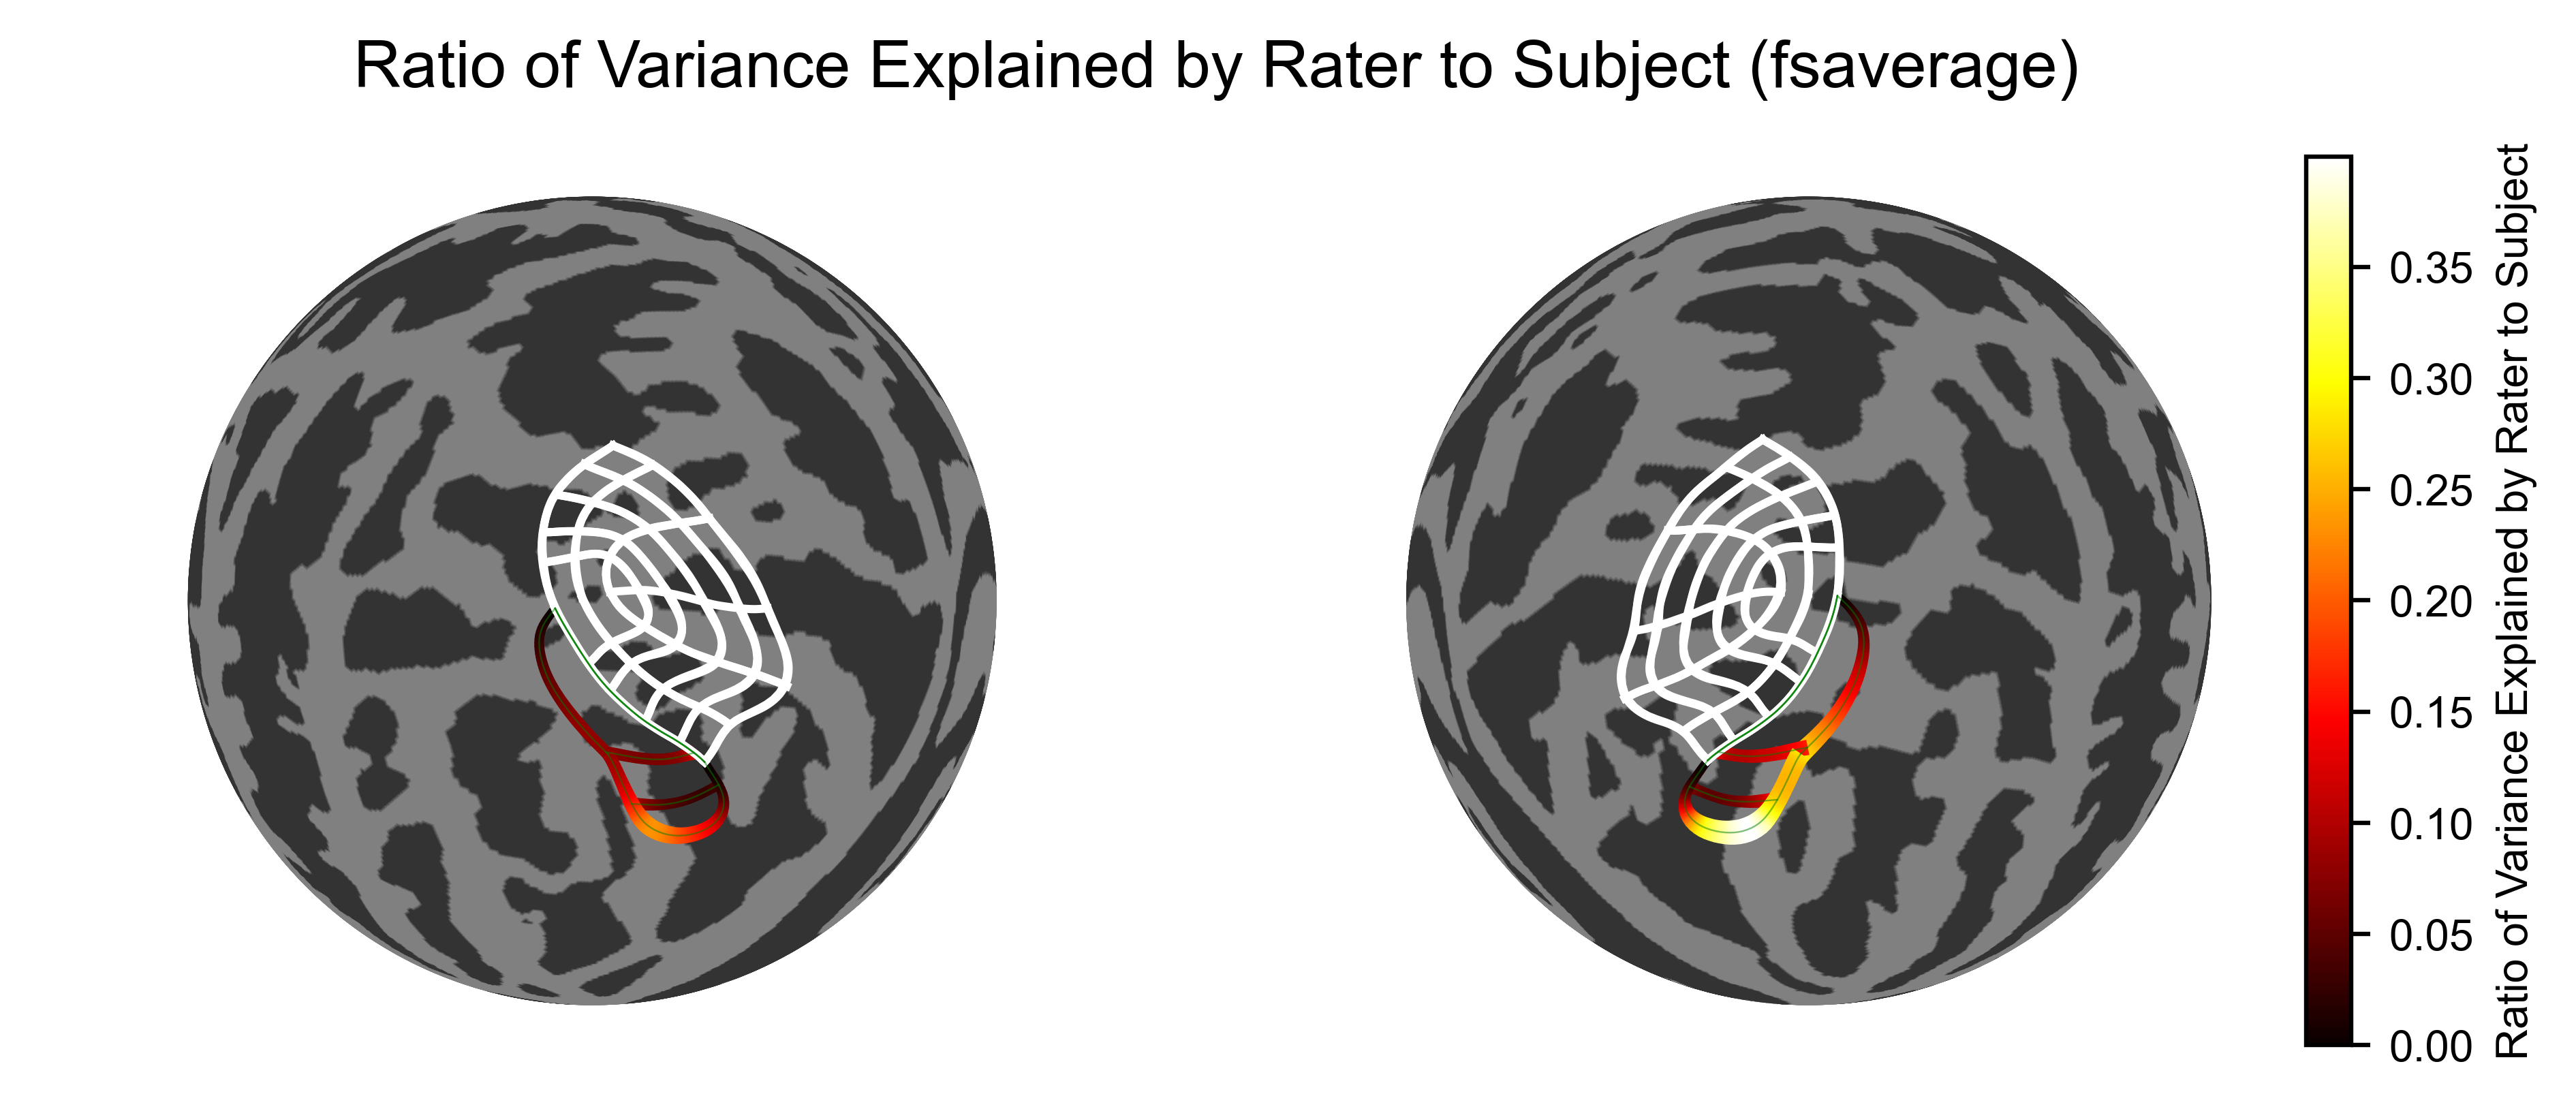

In [18]:
(fig, ax) = plt.subplots(1, 2, figsize=(8,3), dpi=72*8)
fig.suptitle('Ratio of Variance Explained by Rater to Subject (fsaverage)')

for i, hemi in enumerate(['lh', 'rh']):

    ax[i].axis('equal')
    ax[i].axis('off')
    
    hmap = hcpannot.analysis.plot_lw(result_ave, hemi, sub_contours, flatmap=True, contour_save_path=contour_save_path, proc_path=proc_path, ax=ax[i])
    
# format the plot
cb = fig.colorbar(hmap)
cb.ax.tick_params(labelsize=8)
cb.set_label('Ratio of Variance Explained by Rater to Subject', size=8)

# plt.savefig('images/rater2sbj_variance_fsaverage_cortex.pdf')

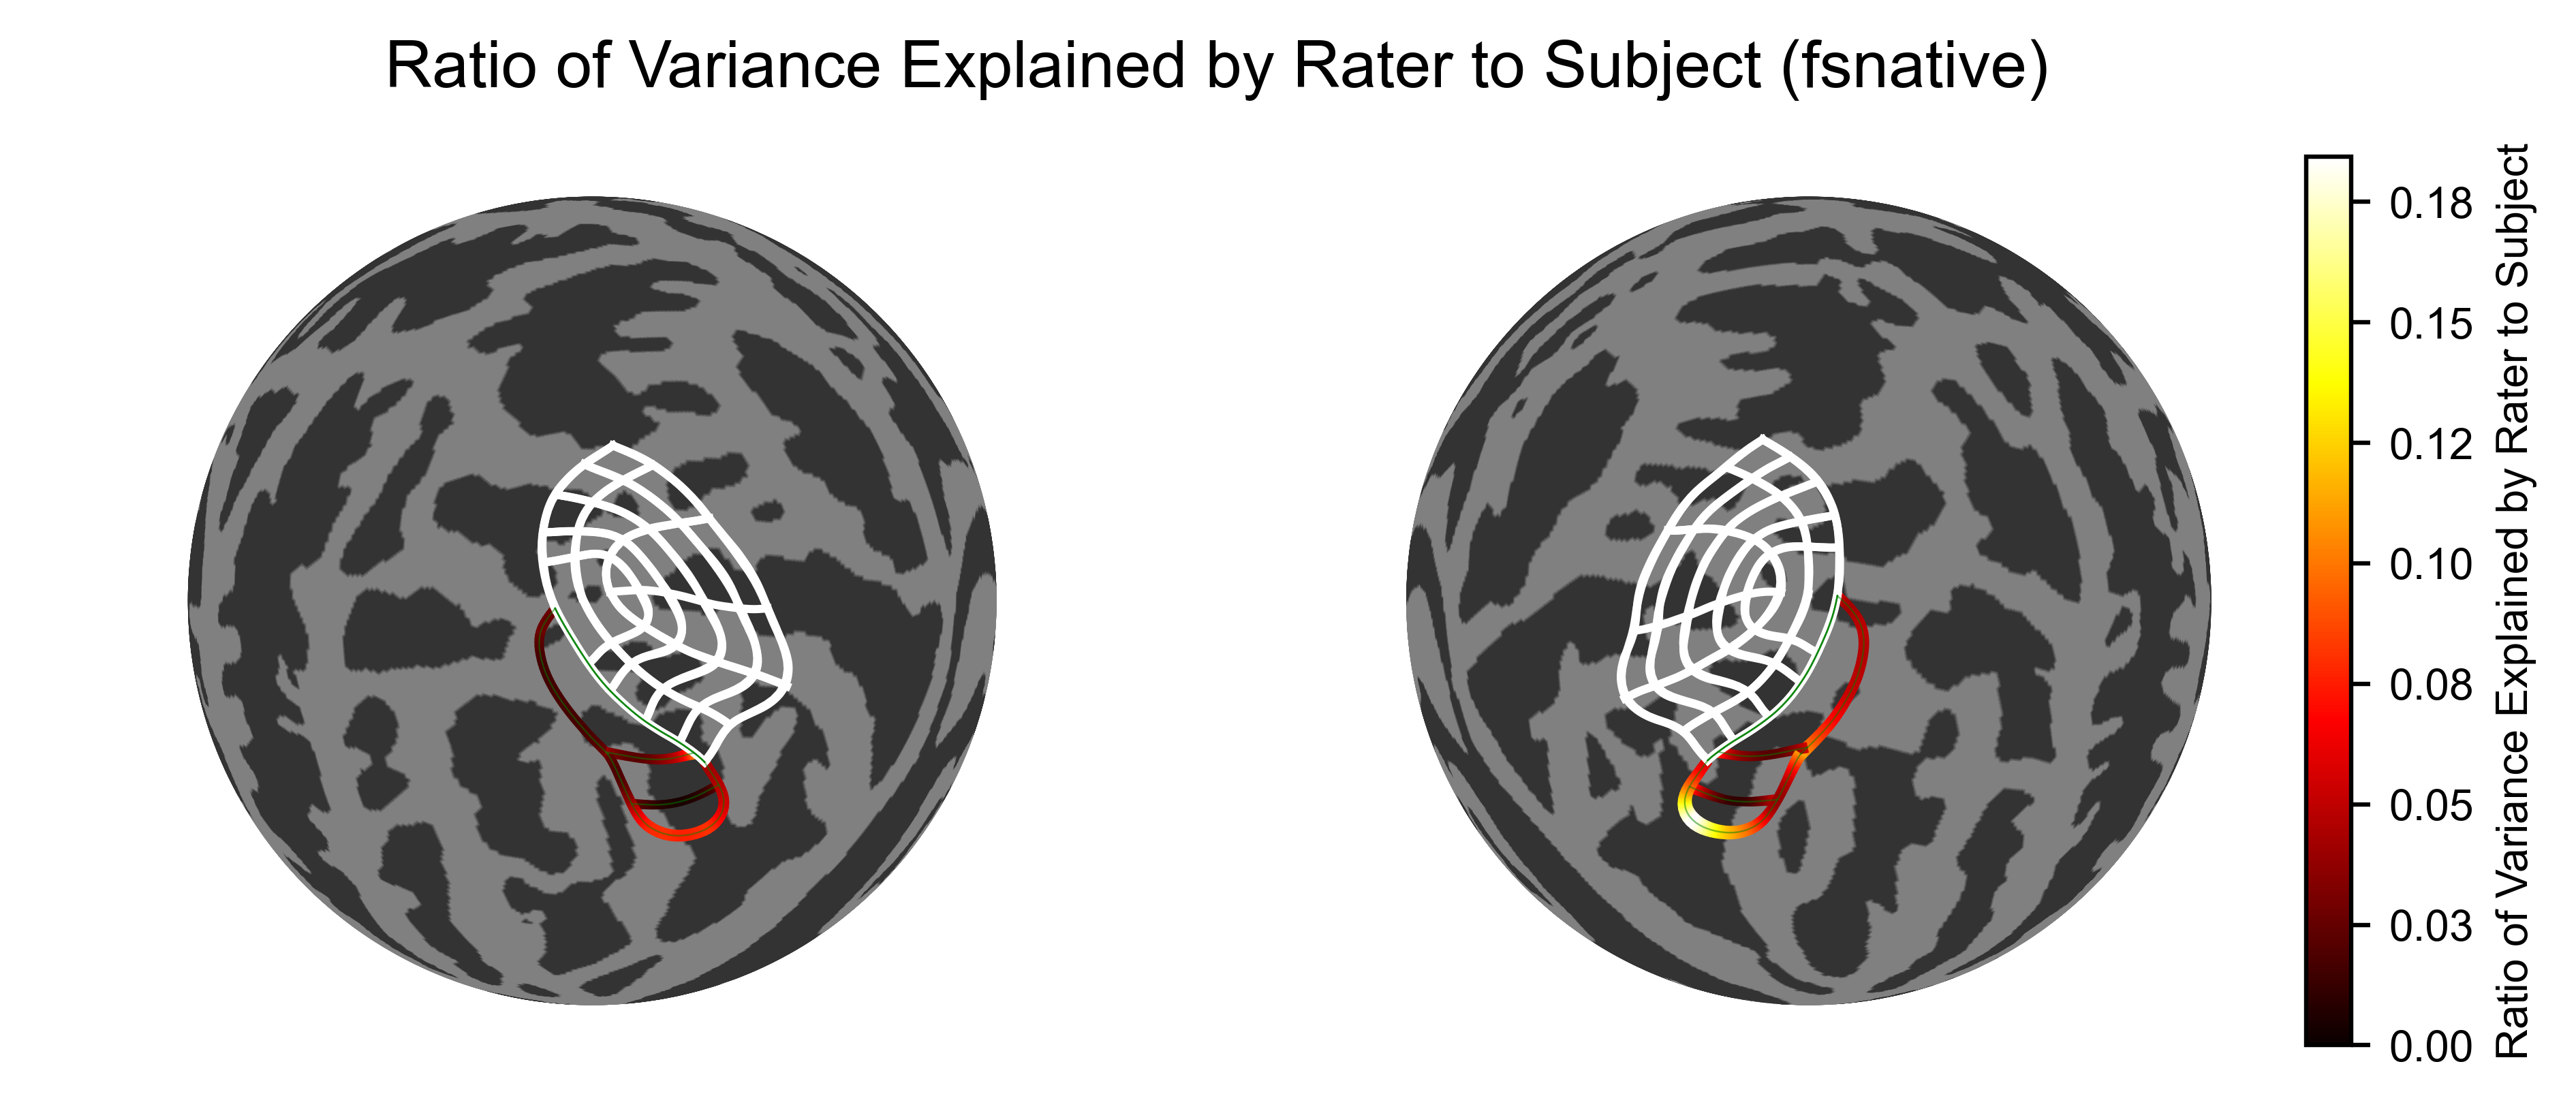

In [19]:
(fig, ax) = plt.subplots(1, 2, figsize=(8,3), dpi=72*8)
fig.suptitle('Ratio of Variance Explained by Rater to Subject (fsnative)')

for i, hemi in enumerate(['lh', 'rh']):

    ax[i].axis('equal')
    ax[i].axis('off')
    
    hmap = hcpannot.analysis.plot_lw(result_nat, hemi, sub_contours, flatmap=True, contour_save_path=contour_save_path, proc_path=proc_path, ax=ax[i])
    
# format the plot
cb = fig.colorbar(hmap, format='%.2f')
cb.ax.tick_params(labelsize=8)
cb.set_label('Ratio of Variance Explained by Rater to Subject', size=8)

# plt.savefig('images/rater2sbj_variance_fsnative_cortex.pdf')

### Hemispheric Asymmetry

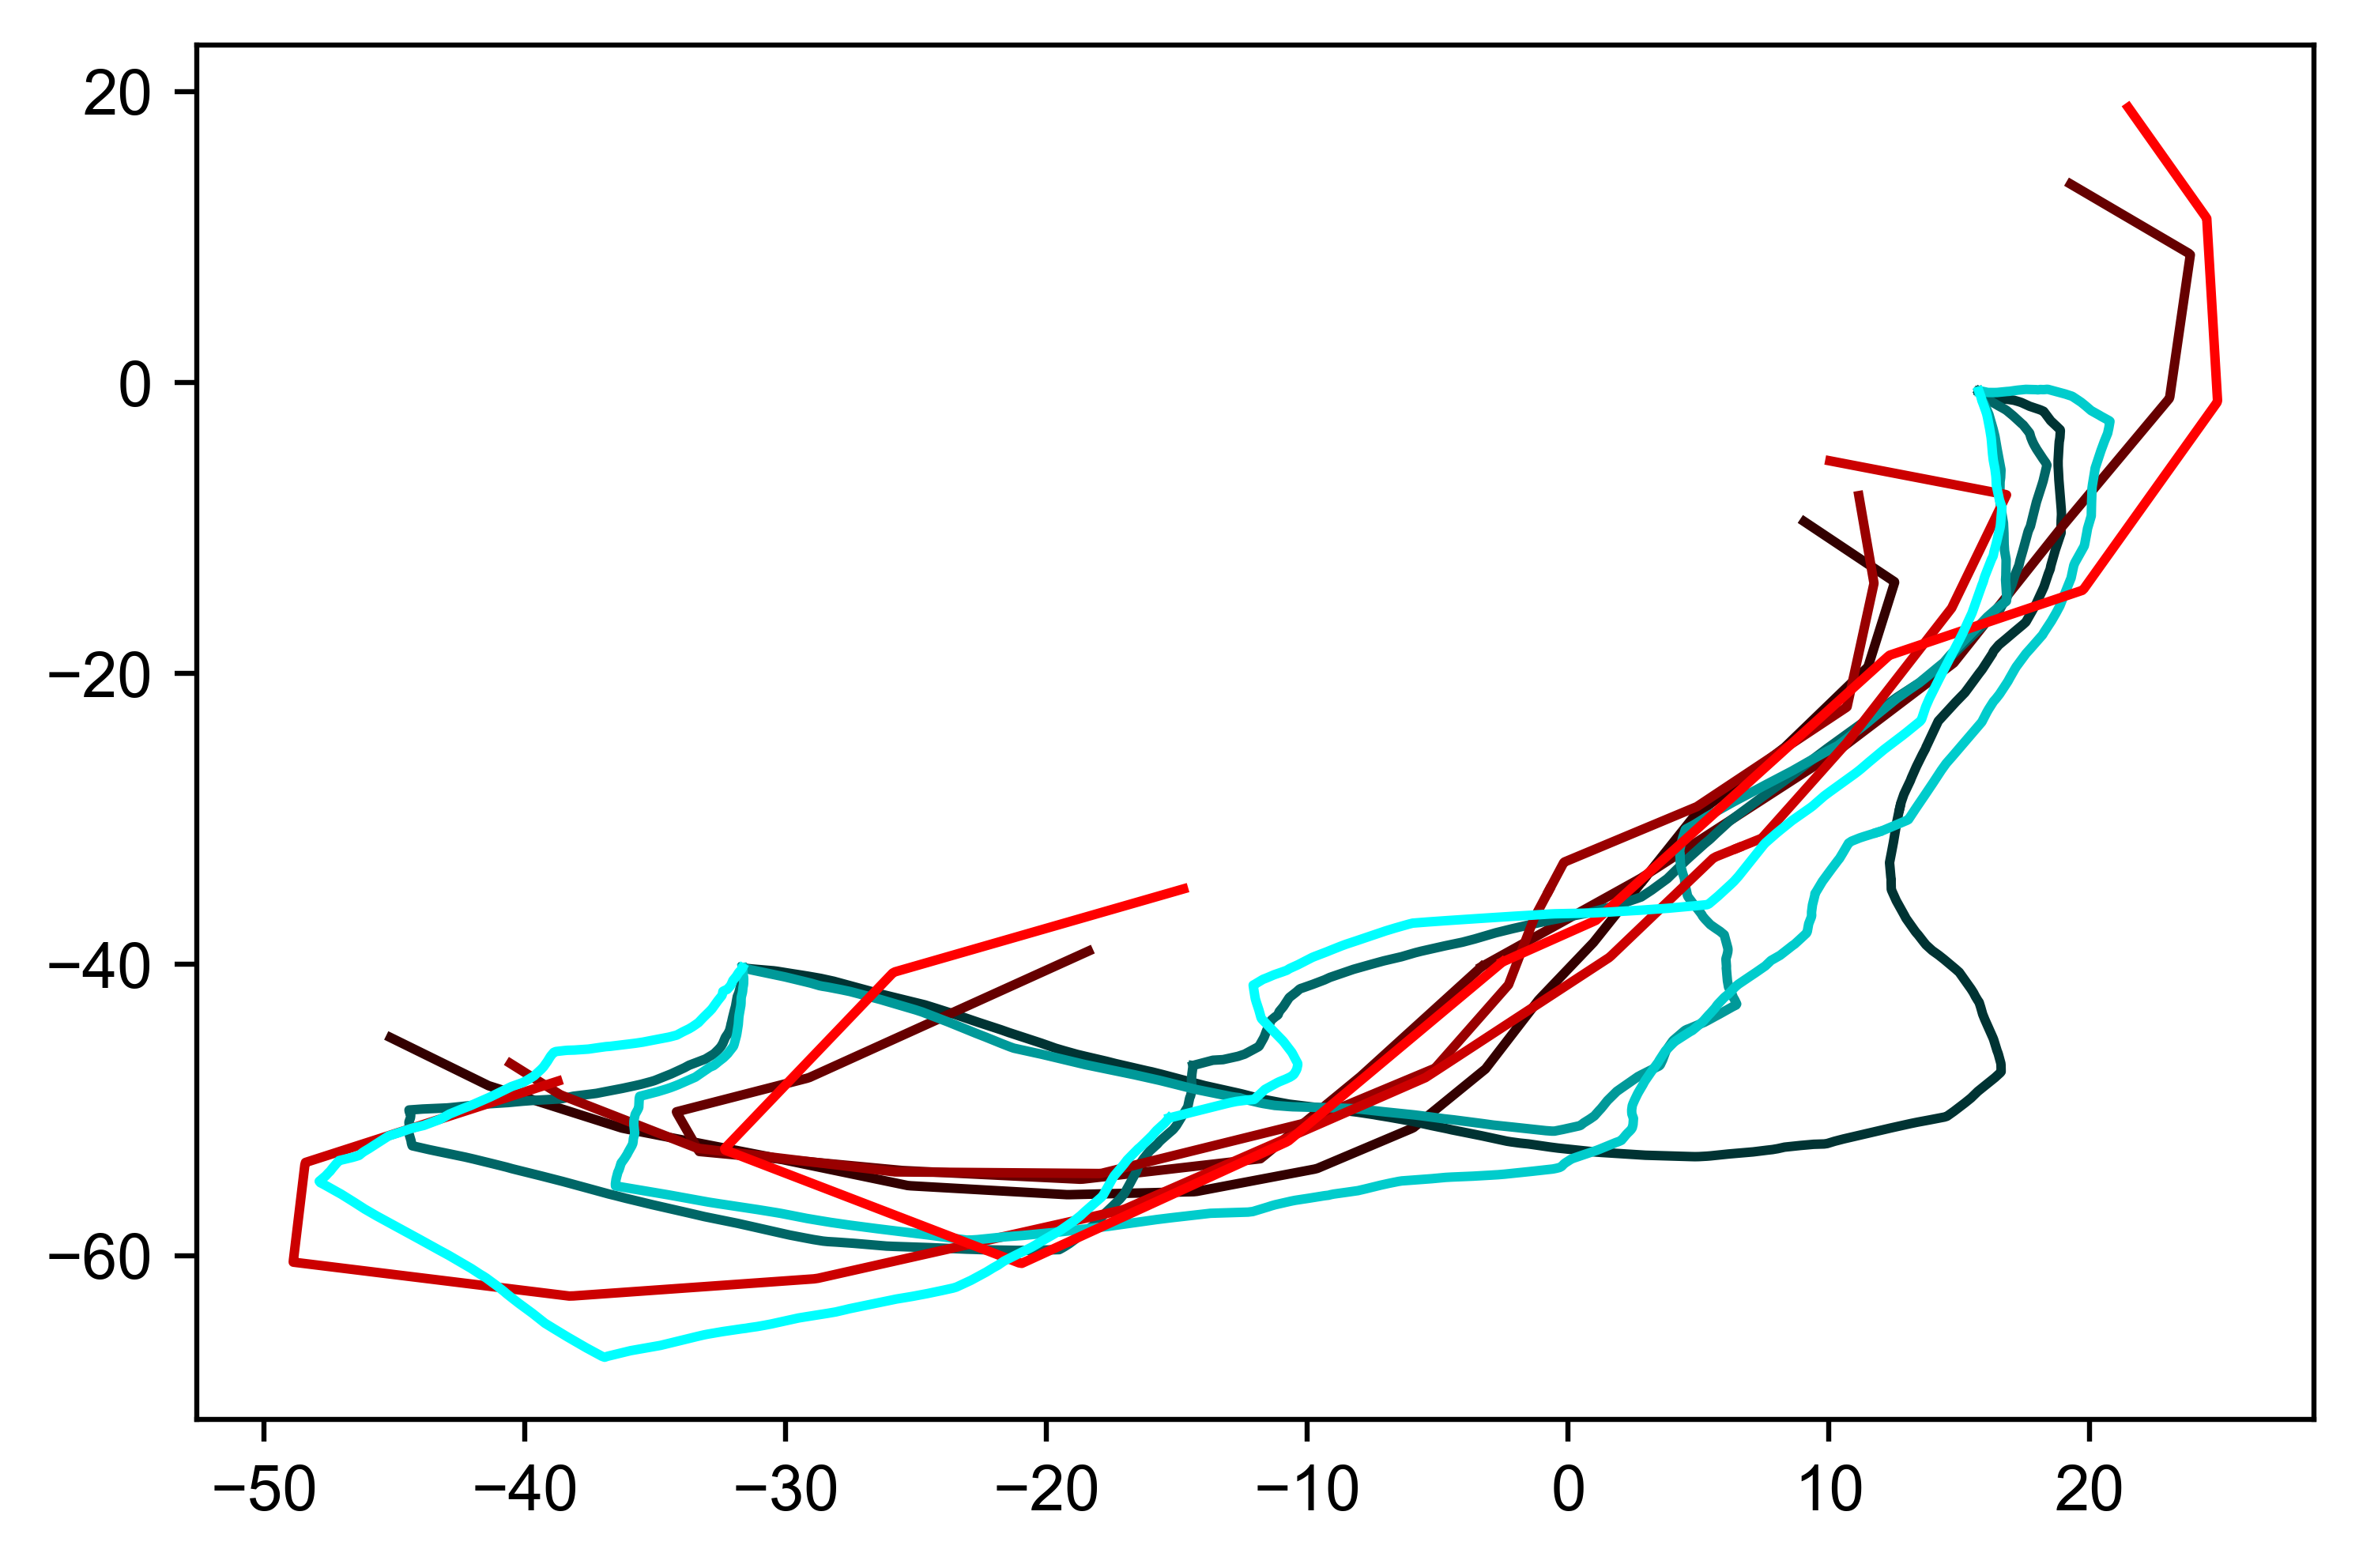

In [20]:
plot_subjects = sids[9:10]

fig, ax = plt.subplots(dpi=72*8)

c1 = np.array([1.0, 0.0, 0.0])
c2 = np.array([0.0, 1.0, 1.0])

hemi = 'rh'

roi = 'VO_outer'

aligned = True

for sid in plot_subjects:
    for ii, r in enumerate(ventral_raters):
        
        for roi in ['VO_outer', 'hV4_outer']:
            
            if aligned == True:
                dir_name = 'fsnative_aligned'
            else:
                dir_name = 'fsnative'
        
            # read fsnative_aligned data
            fsnative_path = os.path.join(proc_path, dir_name, f"cacherater_{r}_{sid}_{hemi}_{roi}.mgz")
            fsnative_data = ny.load(fsnative_path)
            x_coords = fsnative_data[0]
            y_coords = fsnative_data[1]
            
            ax.plot(x_coords, y_coords, '-', c=(1+ii)/len(ventral_raters)*c1)
            
            # read fsaverage data
            fsaverage_path = os.path.join(proc_path, 'fsaverage', f"cacherater_{r}_{sid}_{hemi}_{roi}.mgz")
            fsaverage_data = ny.load(fsaverage_path)
            x_coords = fsaverage_data[0]
            y_coords = fsaverage_data[1]
            
            ax.plot(x_coords, y_coords, '-', c=(1+ii)/len(ventral_raters)*c2)
            
            # fsnative_path = os.path.join(proc_path, 'fsnative', f"cacherater_{r}_{sid}_{hemi}_{roi}.mgz")
            # fsnative_data = ny.load(fsnative_path)
            # x_coords = fsnative_data[0]
            # y_coords = fsnative_data[1]
            
            # ax.plot(x_coords, y_coords, '-', c=(1+ii)/len(ventral_raters)*c1)
            

(-80.0, 20.0)

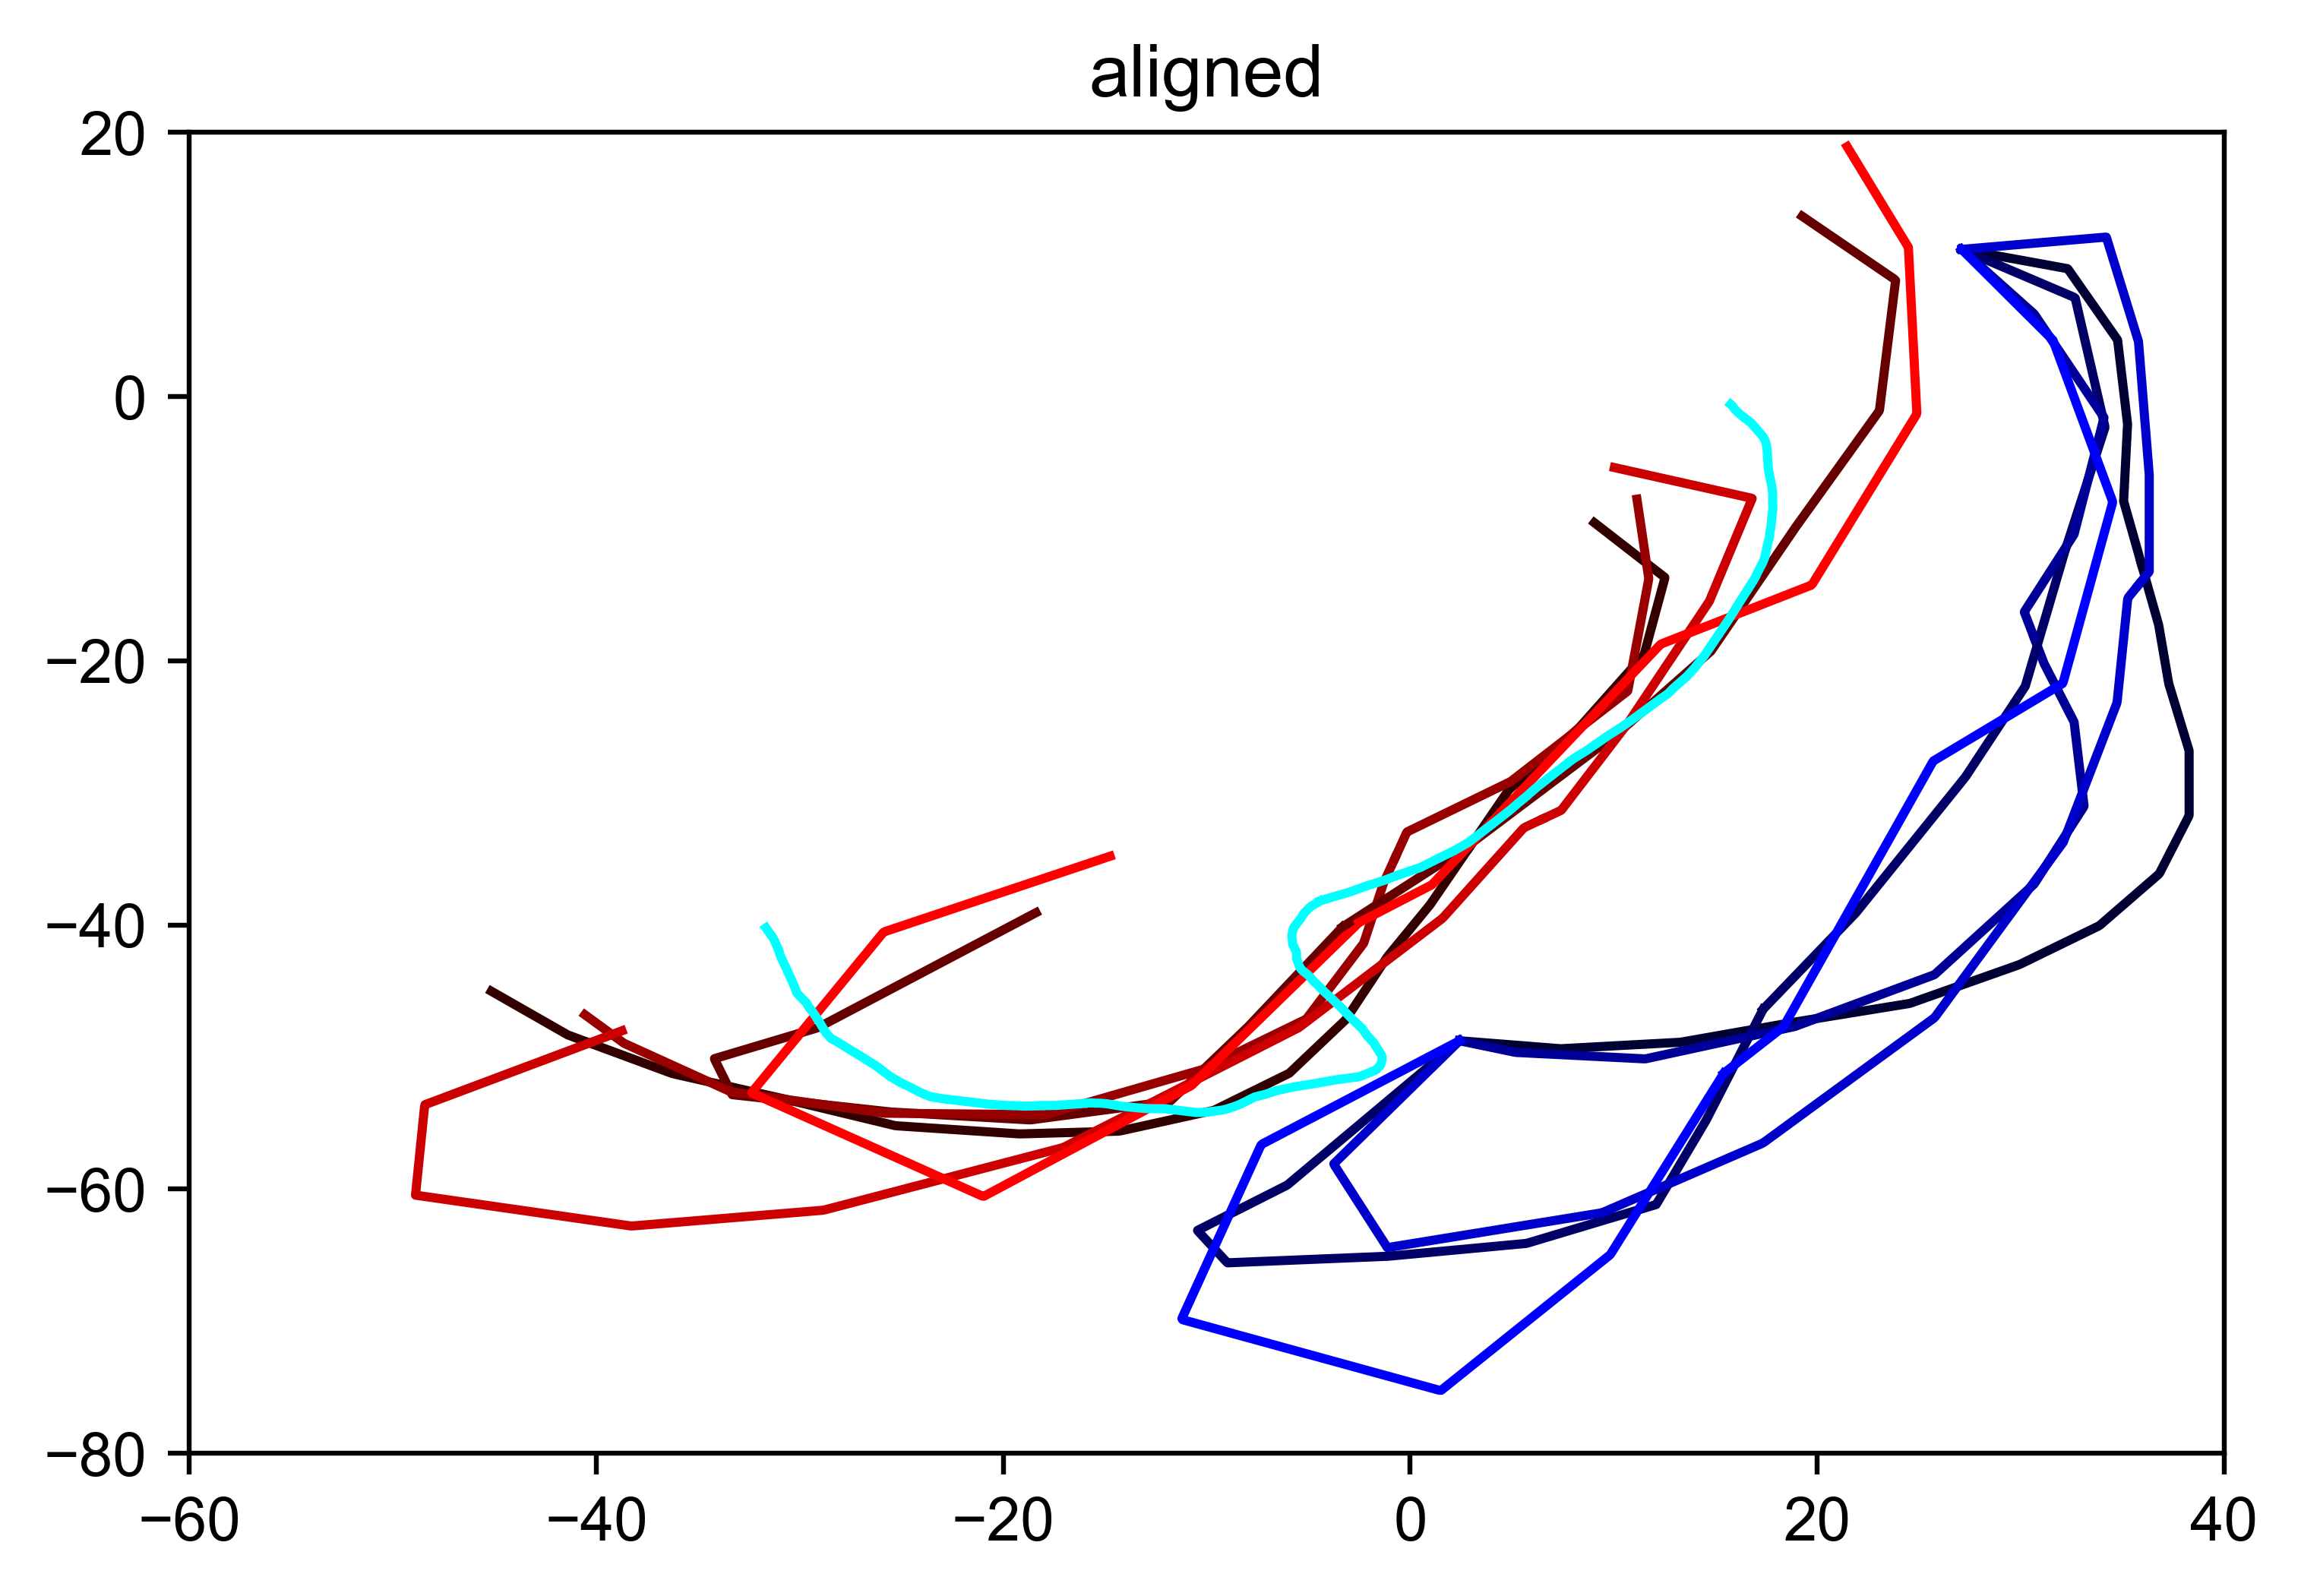

In [21]:
plot_subjects = sids[9:10]

fig, ax = plt.subplots(dpi=72*8)

c1 = np.array([1.0, 0.0, 0.0])
c2 = np.array([0.0, 1.0, 1.0])
c3 = np.array([0.0, 0.0, 1.0])

hemi = 'rh'

roi = 'VO_outer'

aligned = True

for sid in plot_subjects:
    for roi in ['VO_outer', 'hV4_outer']:
        for ii, r in enumerate(ventral_raters):
        
            # read fsnative_aligned data
            fsnative_path = os.path.join(proc_path, 'fsnative_aligned', f"cacherater_{r}_{sid}_{hemi}_{roi}.mgz")
            fsnative_data = ny.load(fsnative_path)
            x_coords = fsnative_data[0]
            y_coords = fsnative_data[1]
            
            ax.plot(x_coords, y_coords, '-', c=(1+ii)/len(ventral_raters)*c1)
            
            fsnative_path = os.path.join(proc_path, 'fsnative', f"cacherater_{r}_{sid}_{hemi}_{roi}.mgz")
            fsnative_data = ny.load(fsnative_path)
            x_coords = fsnative_data[0]
            y_coords = fsnative_data[1]
            
            ax.plot(x_coords, y_coords, '-', c=(1+ii)/len(ventral_raters)*c3)

        r = 'mean'
        
        # read fsaverage data
        fsaverage_path = os.path.join(proc_path, 'fsaverage', f"cacherater_{r}_{sid}_{hemi}_{roi}.mgz")
        fsaverage_data = ny.load(fsaverage_path)
        x_coords = fsaverage_data[0]
        y_coords = fsaverage_data[1]
        
        ax.plot(x_coords, y_coords, '-', c=c2)   
        
ax.set_title('aligned')
ax.set_xlim(-60, 40)
ax.set_ylim(-80, 20)